In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc
import spatialdata as sd

from scipy.stats import spearmanr

In [2]:
# Load spatialdata object
sdata = sd.read_zarr("../data/results/xenium_dapi_cellfeaturizer.sdata.zarr")

# **ViT-MAE interpretation**

In [3]:
# Load the Anndata object containing the ViT-MAE patch embeddings and CellFeaturizer results
vit = sdata.tables["ViT-MAE_pretrained_PooledEmbeddings"]

cellfeat = sdata.tables["CellFeaturizer_nucleus"]

In [4]:
# Verify that both anndata objects describe the same set of cells
print(vit.shape)
print(cellfeat.shape)

print(
    np.all(
        vit.obs["cell_id"].values ==
        cellfeat.obs["scportrait_cell_id"].values
    )
)

(4063, 768)
(4063, 7)
True


In [5]:
# Utility functions

def select_extreme_cells(
    values,
    n_cells=20,
    sample_pool=100,
    random_state=42,
):
    """
    Select representative cells from the lowest and highest
    embedding values.

    Parameters
    ----------
    values : ndarray
        One embedding dimension (n_cells,)

    n_cells : int
        Number of cells to display.

    sample_pool : int
        Randomly sample from the lowest/highest sample_pool cells
        instead of taking the absolute extremes.

    Returns
    -------
    lowest_idx
    highest_idx
    """

    values = np.asarray(values)

    sorted_idx = np.argsort(values)

    sample_pool = min(sample_pool, len(values))

    low_pool = sorted_idx[:sample_pool]
    high_pool = sorted_idx[-sample_pool:]

    rng = np.random.default_rng(random_state)

    lowest_idx = rng.choice(
        low_pool,
        n_cells,
        replace=False,
    )

    highest_idx = rng.choice(
        high_pool,
        n_cells,
        replace=False,
    )

    return lowest_idx, highest_idx

In [6]:
def get_image_patch(dataset, idx):
    """
    Retrieve one DAPI image patch.

    Returns
    -------
    image : np.ndarray
        Shape (64, 64)

    cell_id : int
    """

    image, _, cell_id = dataset[idx]

    image = image.squeeze().cpu().numpy()
    cell_id = int(cell_id.item())

    return image, cell_id

In [7]:
def plot_gallery(
    dataset,
    indices,
    values,
    title,
    ncols=5,
):

    n = len(indices)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3*ncols, 3*nrows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices):

        image, cell_id = get_image_patch(dataset, idx)

        ax.imshow(
            image,
            cmap="gray",
            interpolation="nearest"
        )

        ax.set_title(
            f"Cell {cell_id}\n{values[idx]:.2f}",
            fontsize=8
        )

        ax.axis("off")

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)

    plt.tight_layout()

    plt.show()

In [8]:
from pathlib import Path

from scportrait.tools.ml.datasets import H5ScSingleCellDataset

DATA_PATH = Path(
    "../data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc"
)
dataset = H5ScSingleCellDataset(
    dir_list=[DATA_PATH],
    dir_labels=[0],
    select_channel=[1],   # DAPI only
    return_id=True,
)

Total single cell records: 4063


In [9]:
sample = dataset[0]

print(type(sample))
print(len(sample))

for i, x in enumerate(sample):
    print(i, type(x))

<class 'tuple'>
3
0 <class 'torch.Tensor'>
1 <class 'torch.Tensor'>
2 <class 'torch.Tensor'>


In [10]:
image, label, cell_id = dataset[0]

print("Image")
print(image.shape)
print(image.dtype)

print("\nLabel")
print(label)
print(label.shape)

print("\nCell ID")
print(cell_id)
print(cell_id.shape)

Image
torch.Size([1, 64, 64])
torch.float32

Label
tensor(0.)
torch.Size([])

Cell ID
tensor(1)
torch.Size([])


In [11]:
image, _, dataset_cell_id = dataset[0]

print("Dataset cell ID:", int(dataset_cell_id))

print("AnnData cell ID:", vit.obs.iloc[0]["cell_id"])

Dataset cell ID: 1
AnnData cell ID: 1


In [12]:
def correlate_cell_features(
    embedding_values,
    cellfeat,
):
    """
    Correlate one embedding dimension with
    every CellFeaturizer feature.
    """

    results = []

    embedding_values = np.asarray(
        embedding_values
    )

    X = np.asarray(cellfeat.X)

    for i, feature in enumerate(cellfeat.var_names):

        rho, p = spearmanr(
            embedding_values,
            X[:, i],
        )

        results.append(
            [
                feature,
                rho,
                p,
                abs(rho),
            ]
        )

    corr = pd.DataFrame(
        results,
        columns=[
            "Feature",
            "Spearman_rho",
            "P_value",
            "Abs_rho",
        ],
    )

    corr = corr.sort_values(
        "Abs_rho",
        ascending=False,
    )

    return corr

In [13]:
def plot_feature_correlation(
    embedding_values,
    feature_values,
    feature_name,
):

    plt.figure(figsize=(5,5))

    plt.scatter(
        embedding_values,
        feature_values,
        s=8,
        alpha=0.5,
    )

    plt.xlabel("Embedding value")
    plt.ylabel(feature_name)

    plt.tight_layout()

    plt.show()

In [14]:
def analyze_embedding_dimension(
    embedding_dim,
    vit,
    cellfeat,
    dataset,
    n_cells=20,
):

    print("=" * 70)
    print(f"Embedding dimension: {embedding_dim}")
    print("=" * 70)

    embedding = vit.X[:, embedding_dim]

    corr = correlate_cell_features(
        embedding,
        cellfeat,
    )

    print("\nTop correlated CellFeaturizer features\n")

    display(corr.head(10))

    low_idx, high_idx = select_extreme_cells(
        embedding,
        n_cells=n_cells,
    )

    plot_gallery(
        dataset,
        low_idx,
        embedding,
        "Lowest embedding values",
    )

    plot_gallery(
        dataset,
        high_idx,
        embedding,
        "Highest embedding values",
    )

    return corr

Embedding dimension: 103

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
5,DAPI_summed_intensity_nucleus,0.997534,0.0,0.997534
2,DAPI_median_nucleus,0.949368,0.0,0.949368
0,nucleus_area,0.909657,0.0,0.909657
4,DAPI_quant25_nucleus,0.891920,0.0,0.891920
1,DAPI_mean_nucleus,0.849303,0.0,0.849303
6,DAPI_summed_intensity_area_normalized_nucleus,0.849303,0.0,0.849303
3,DAPI_quant75_nucleus,0.723803,0.0,0.723803


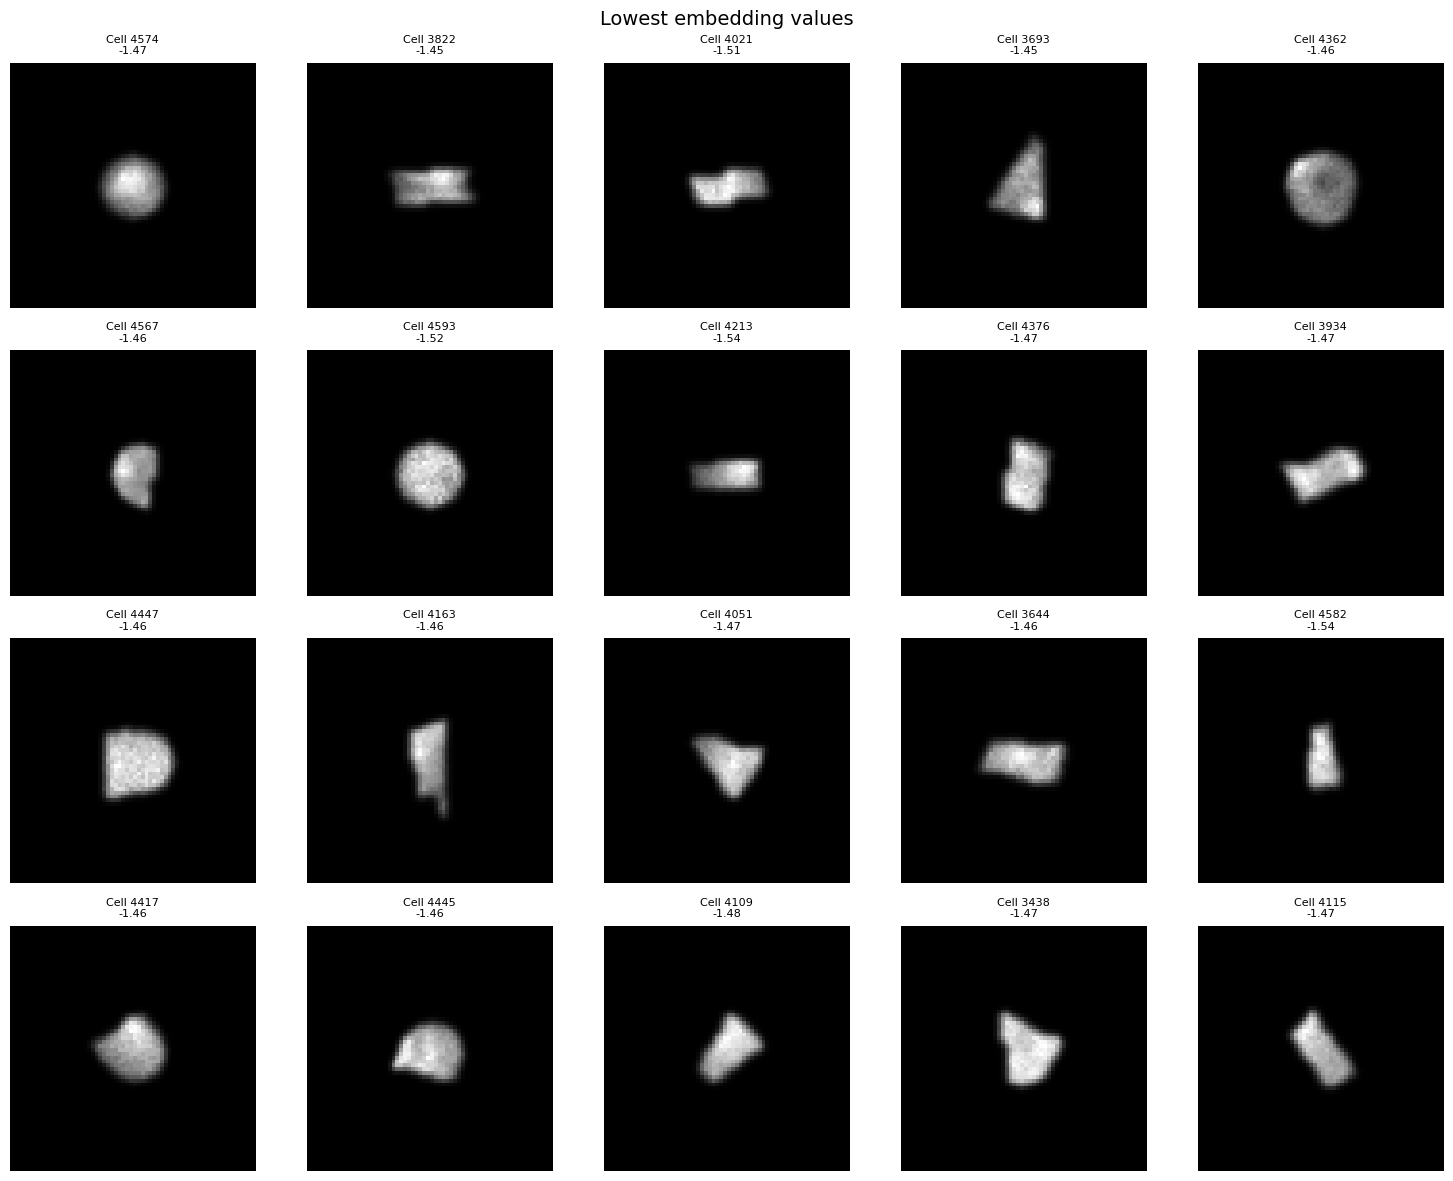

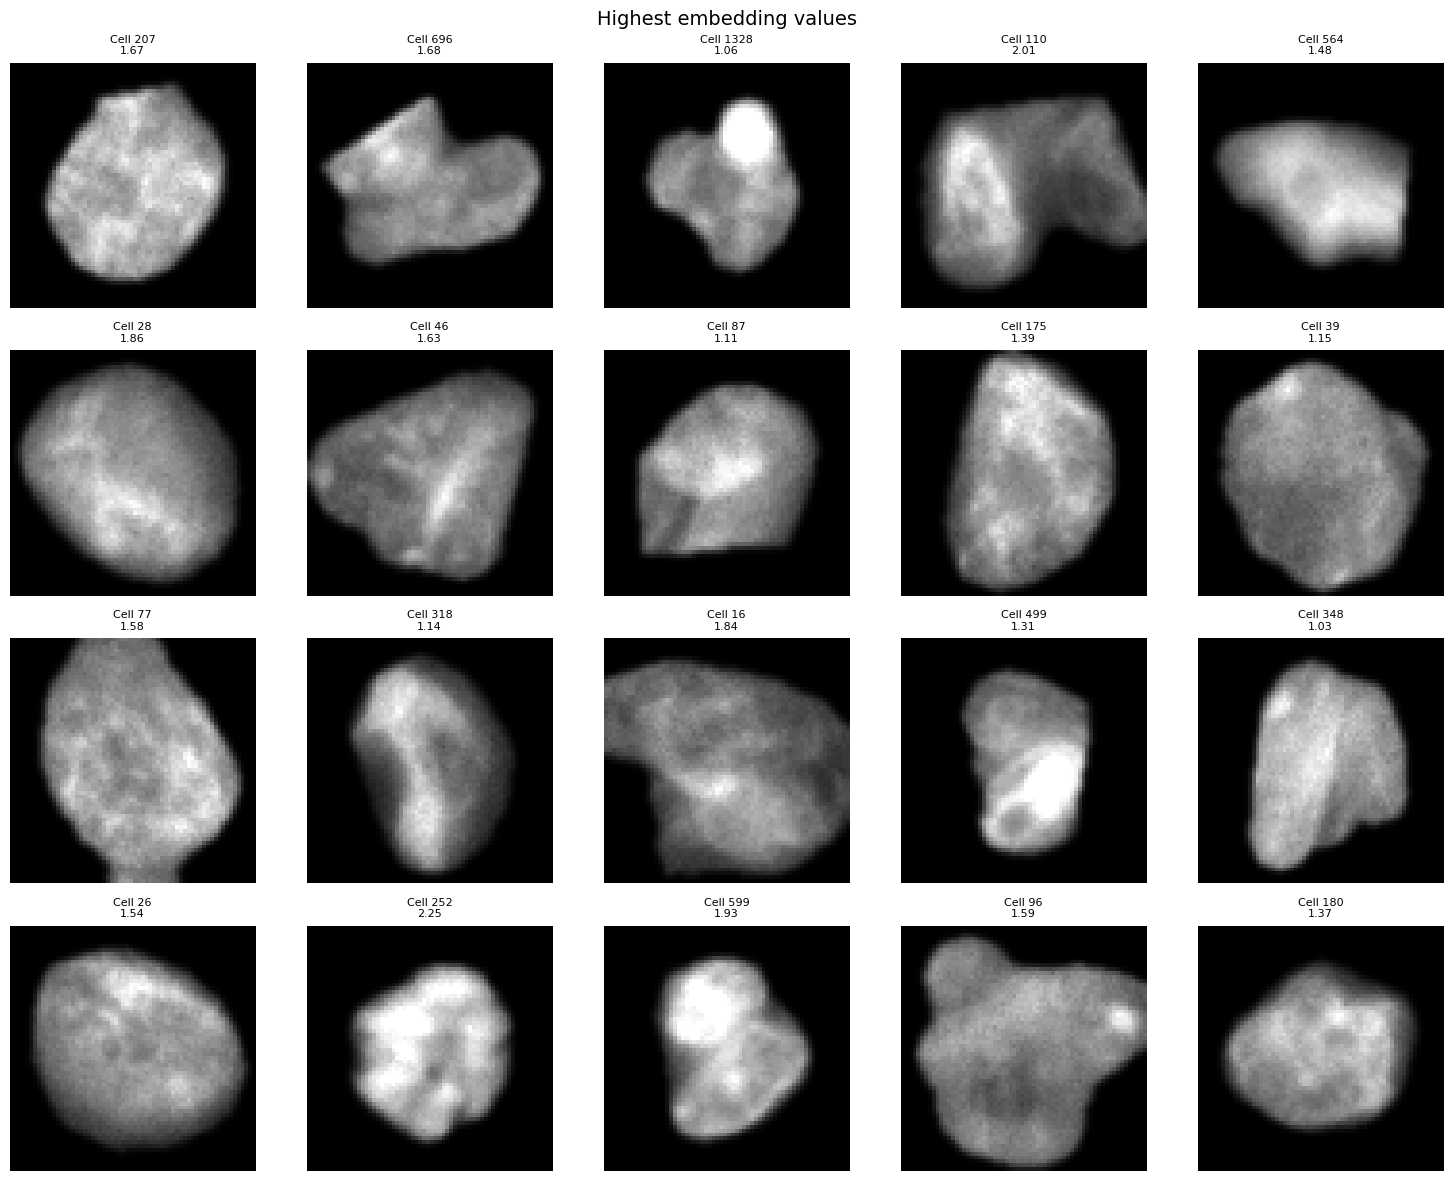

Embedding dimension: 457

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
5,DAPI_summed_intensity_nucleus,-0.872651,0.0,0.872651
2,DAPI_median_nucleus,-0.828500,0.0,0.828500
1,DAPI_mean_nucleus,-0.816404,0.0,0.816404
6,DAPI_summed_intensity_area_normalized_nucleus,-0.816404,0.0,0.816404
4,DAPI_quant25_nucleus,-0.744175,0.0,0.744175
0,nucleus_area,-0.739150,0.0,0.739150
3,DAPI_quant75_nucleus,-0.720092,0.0,0.720092


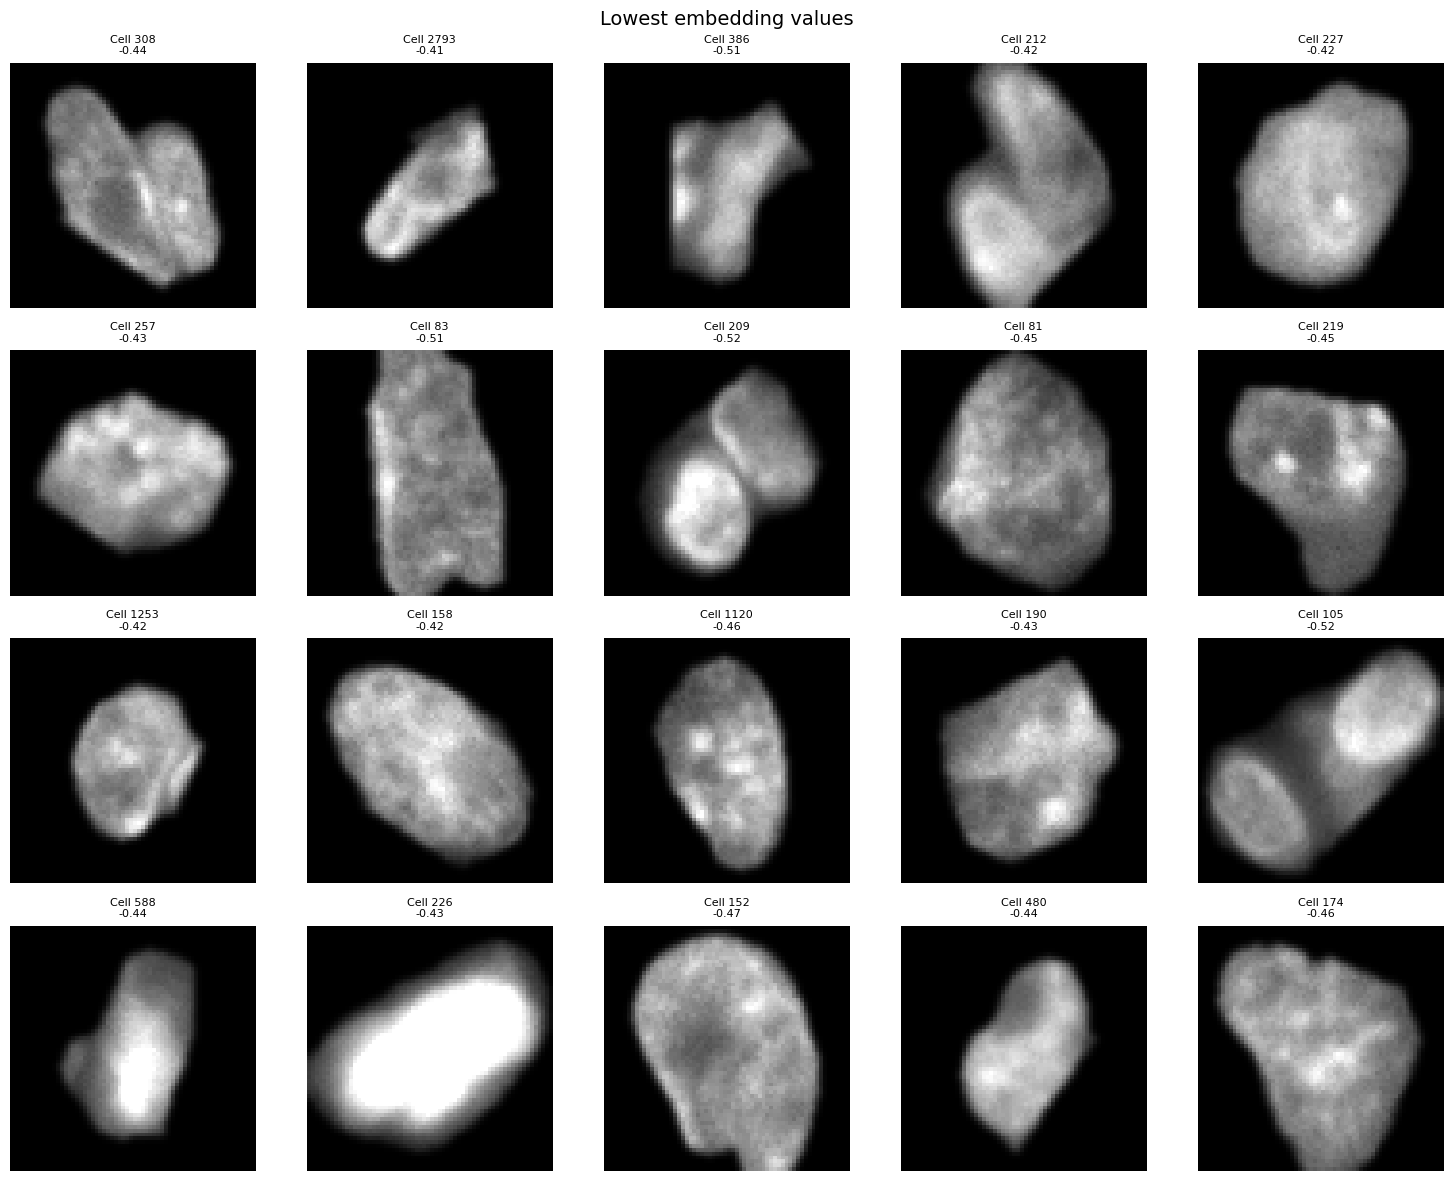

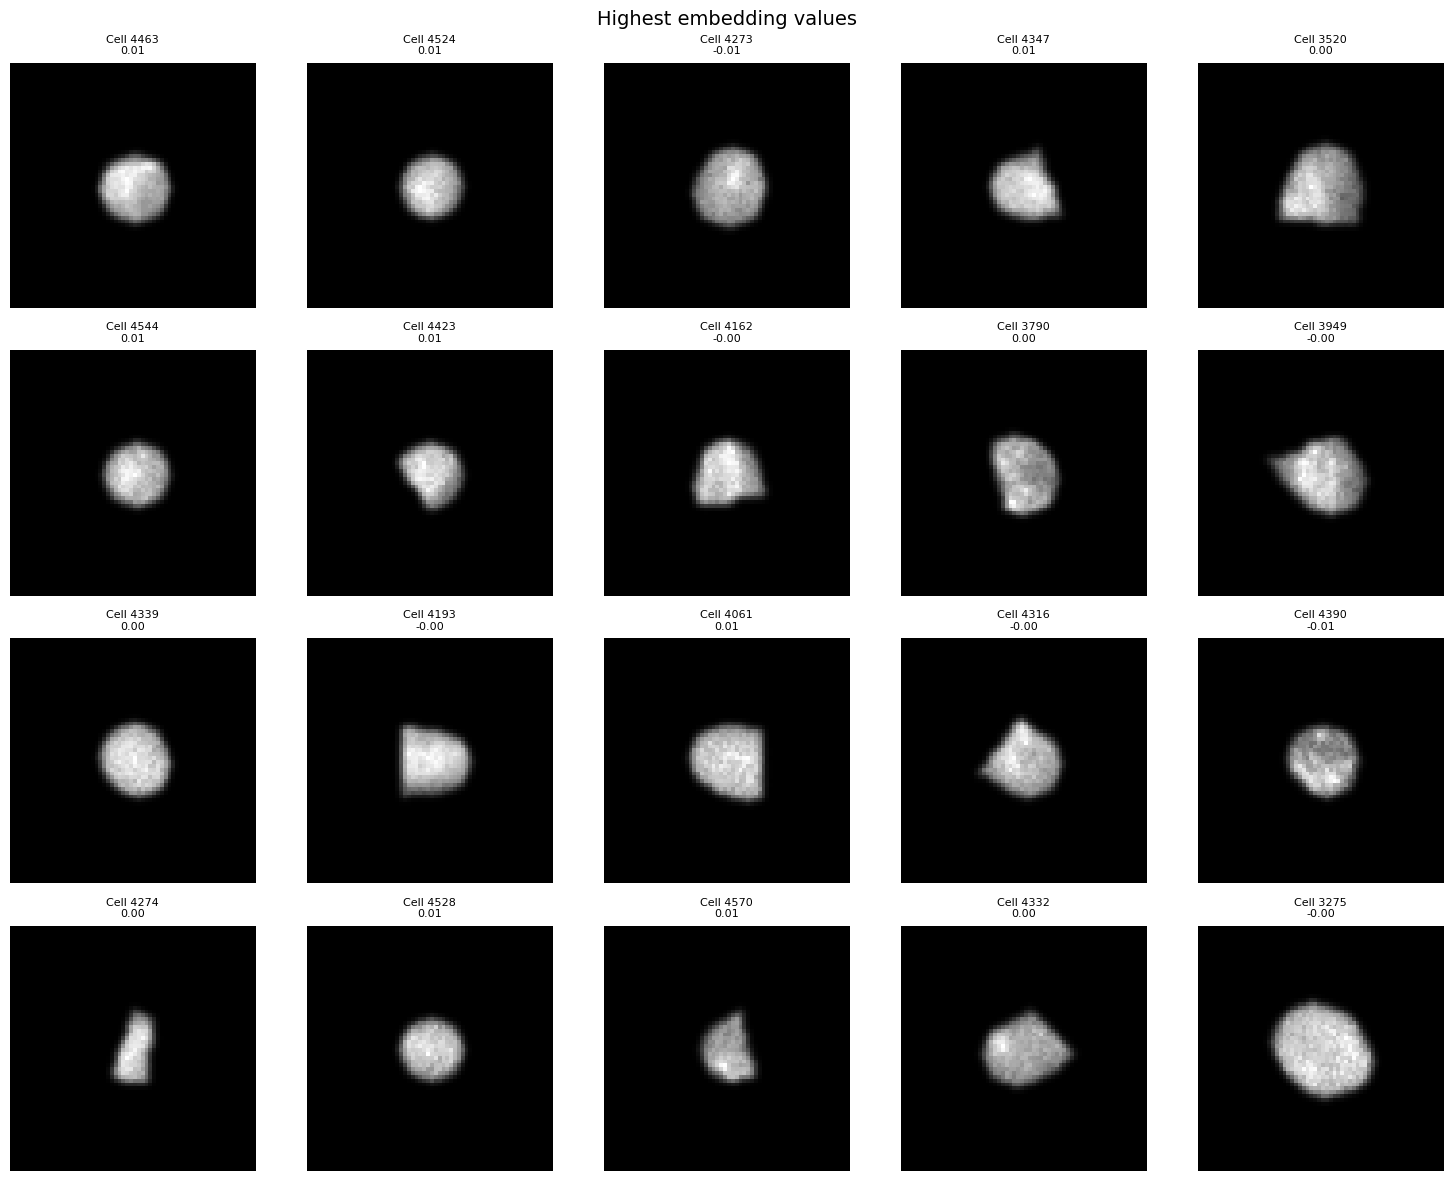

Embedding dimension: 304

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
4,DAPI_quant25_nucleus,-0.392323,1.303423e-149,0.392323
0,nucleus_area,-0.387667,7.888879e-146,0.387667
3,DAPI_quant75_nucleus,0.351176,3.058960e-118,0.351176
6,DAPI_summed_intensity_area_normalized_nucleus,0.227834,5.403963e-49,0.227834
1,DAPI_mean_nucleus,0.227834,5.403963e-49,0.227834
2,DAPI_median_nucleus,-0.171466,3.504471e-28,0.171466
5,DAPI_summed_intensity_nucleus,-0.088793,1.433932e-08,0.088793


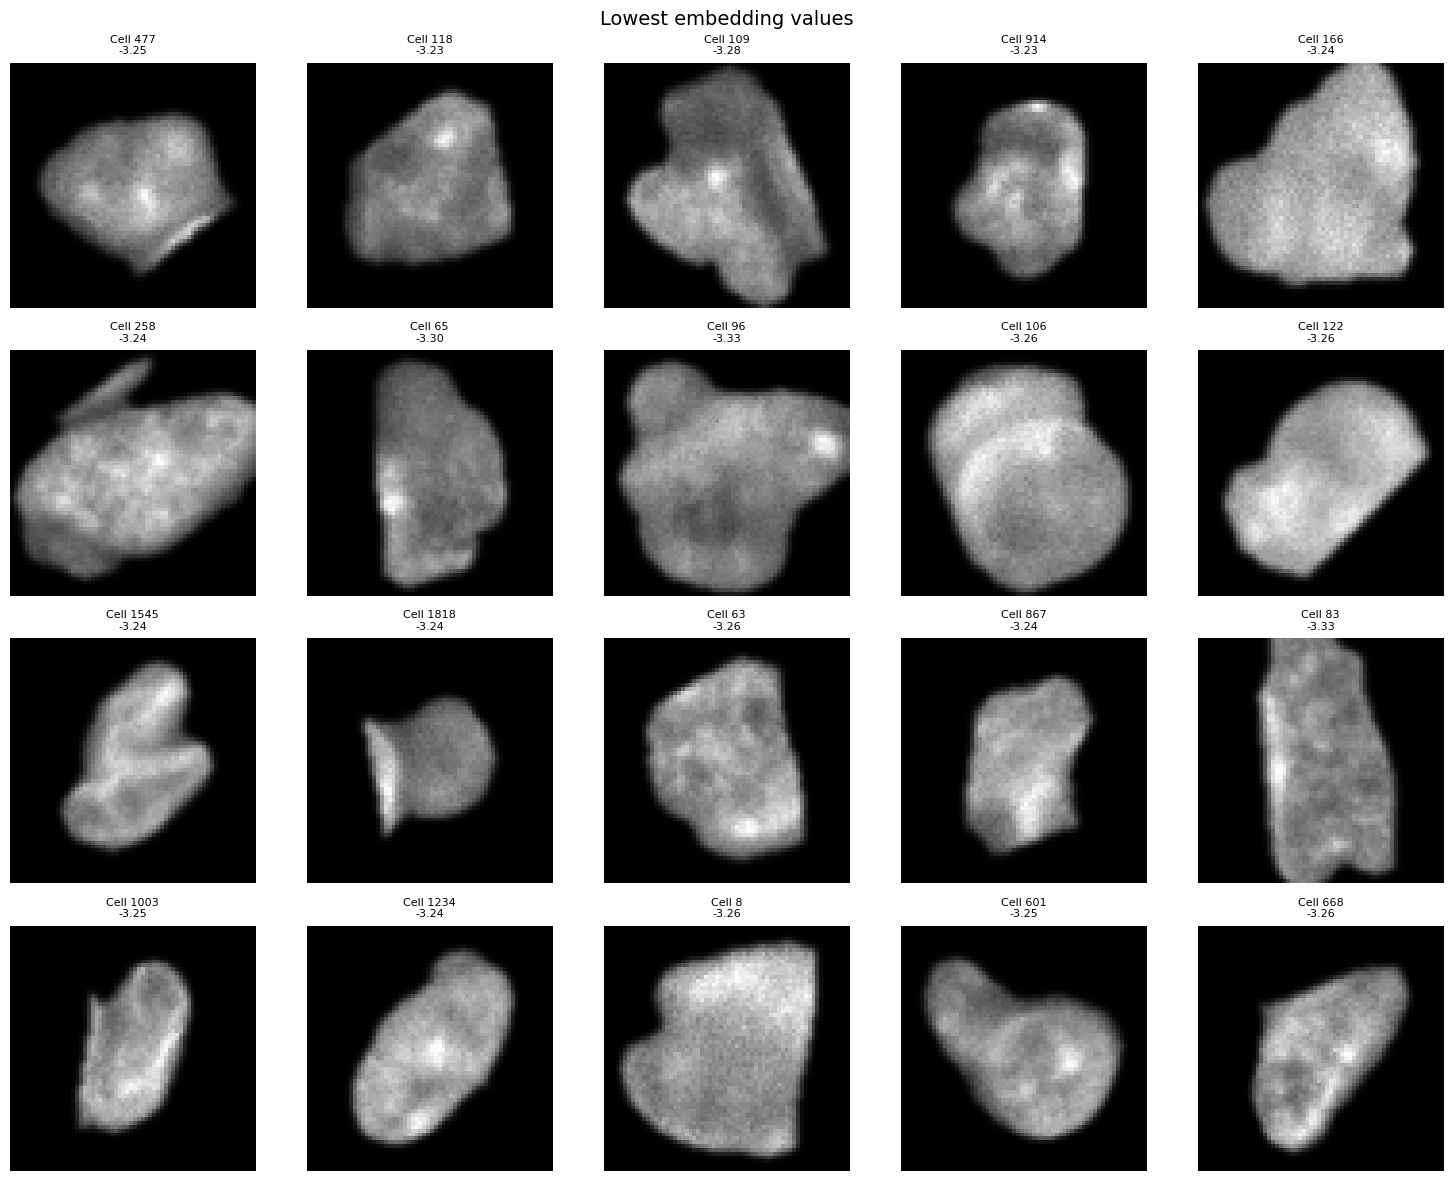

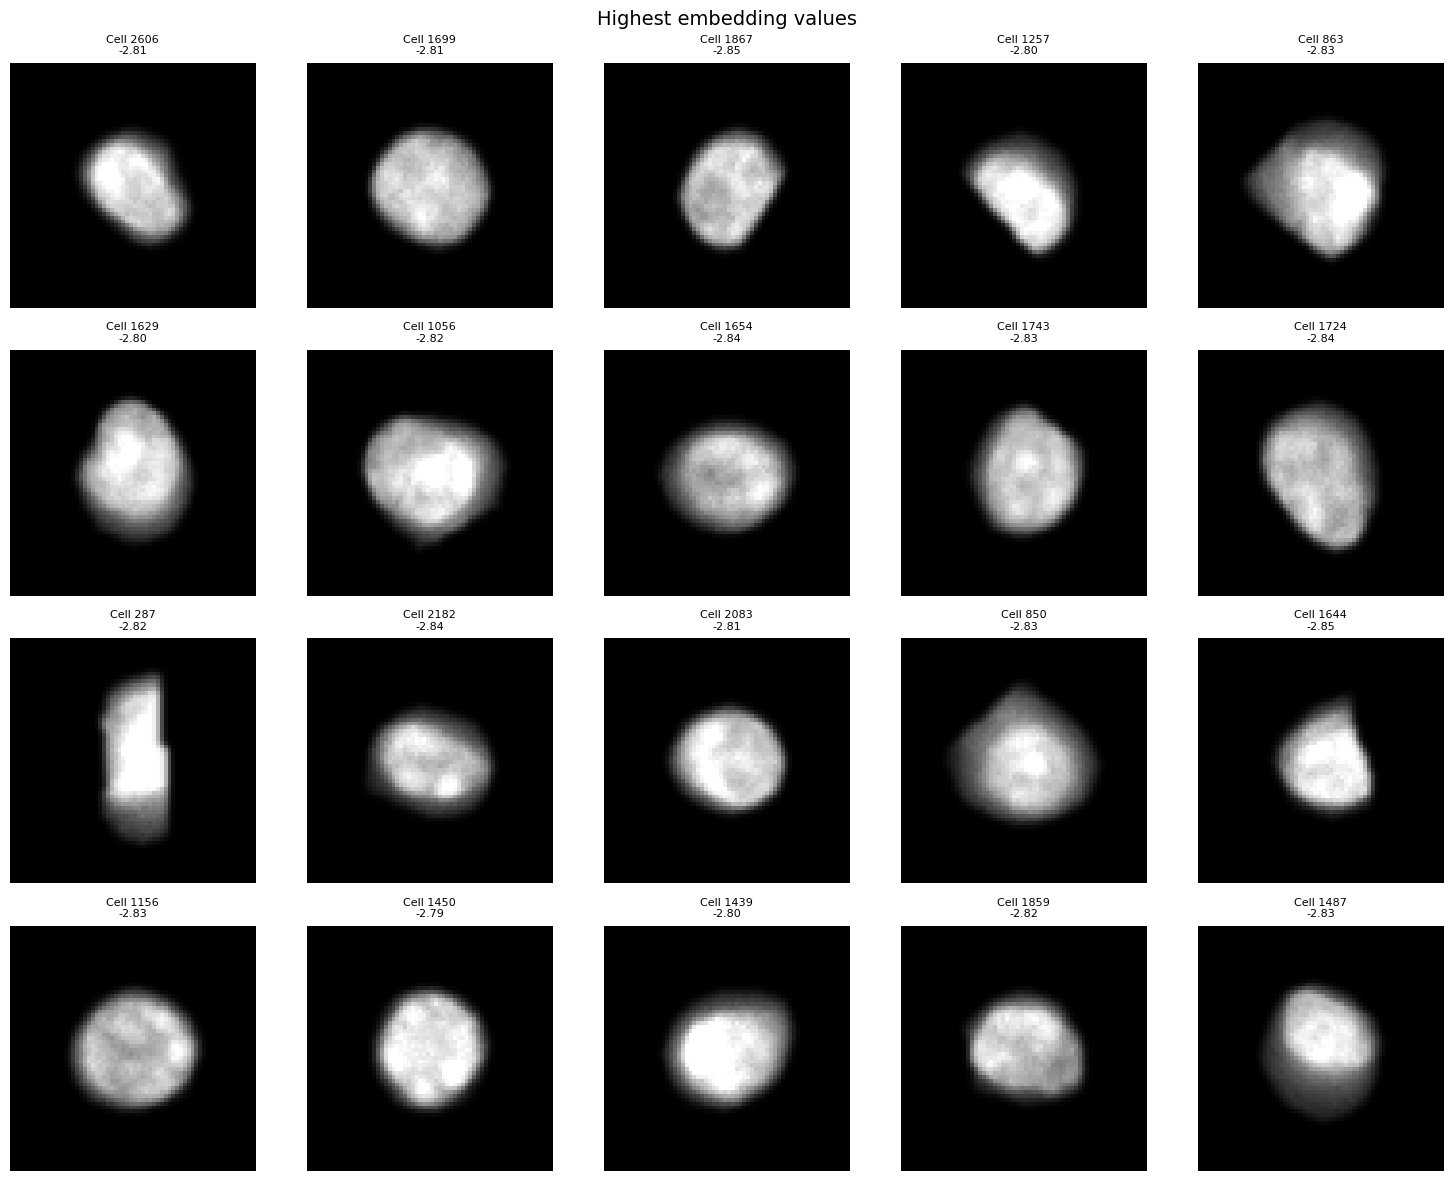

Embedding dimension: 223

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
5,DAPI_summed_intensity_nucleus,-0.934541,0.0,0.934541
2,DAPI_median_nucleus,-0.878749,0.0,0.878749
0,nucleus_area,-0.856696,0.0,0.856696
4,DAPI_quant25_nucleus,-0.839073,0.0,0.839073
1,DAPI_mean_nucleus,-0.793828,0.0,0.793828
6,DAPI_summed_intensity_area_normalized_nucleus,-0.793828,0.0,0.793828
3,DAPI_quant75_nucleus,-0.677651,0.0,0.677651


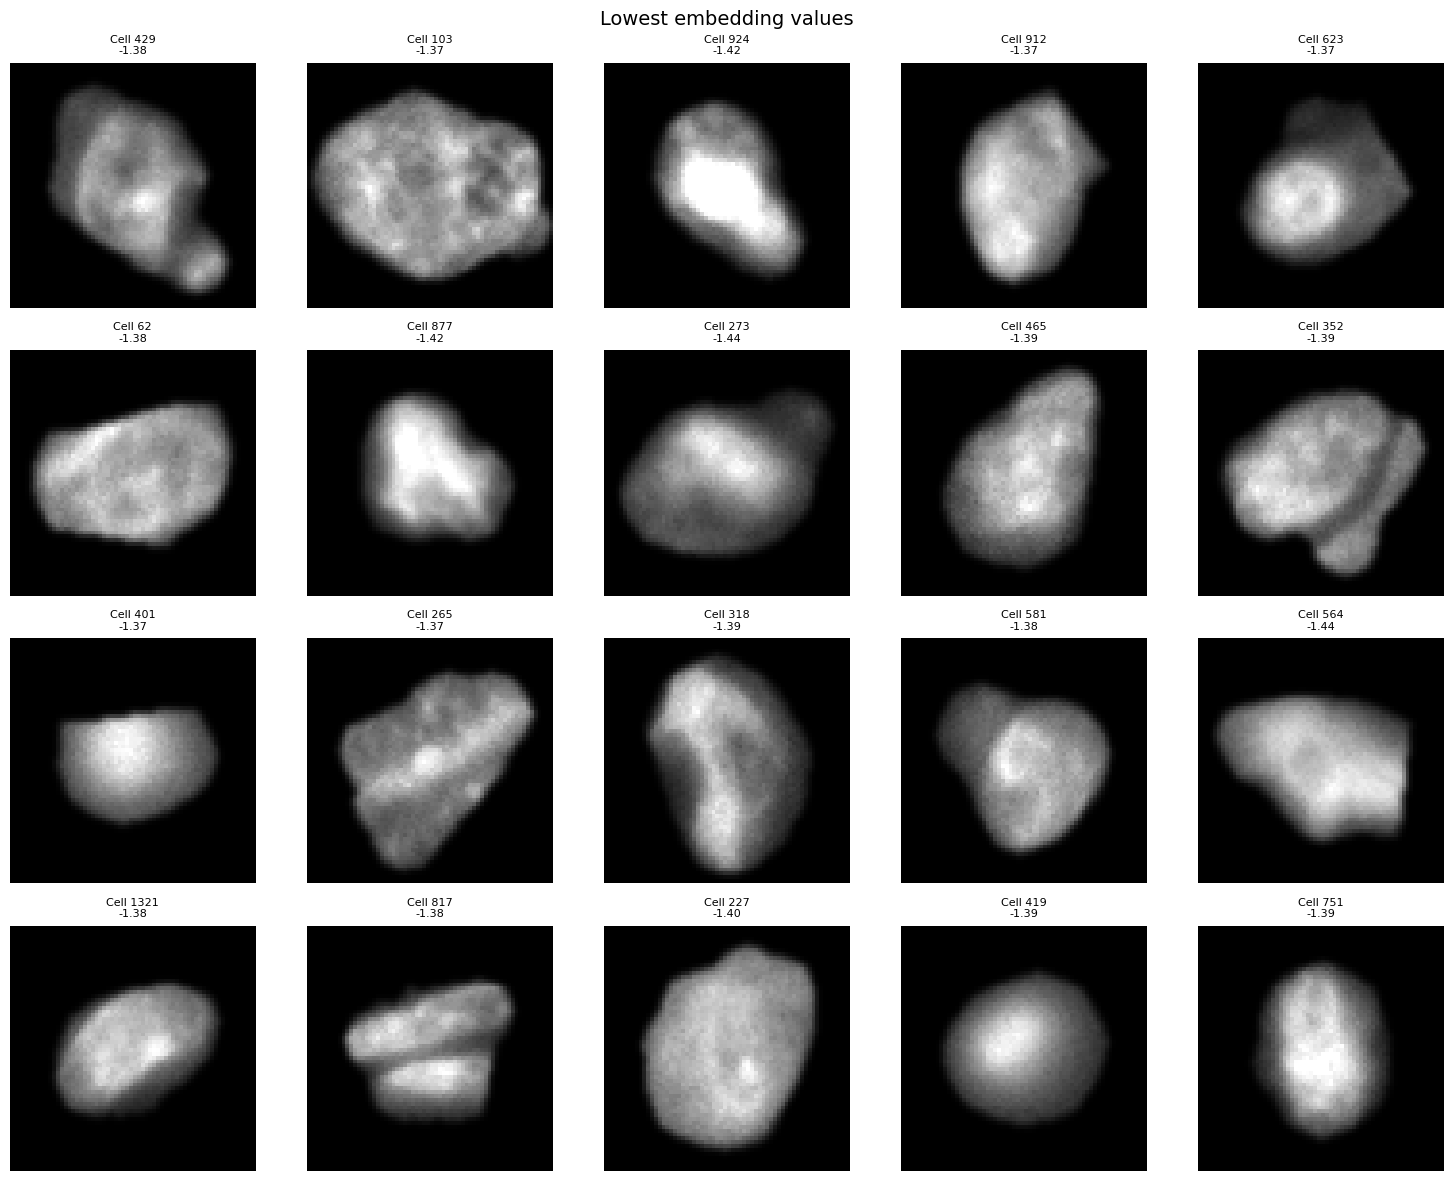

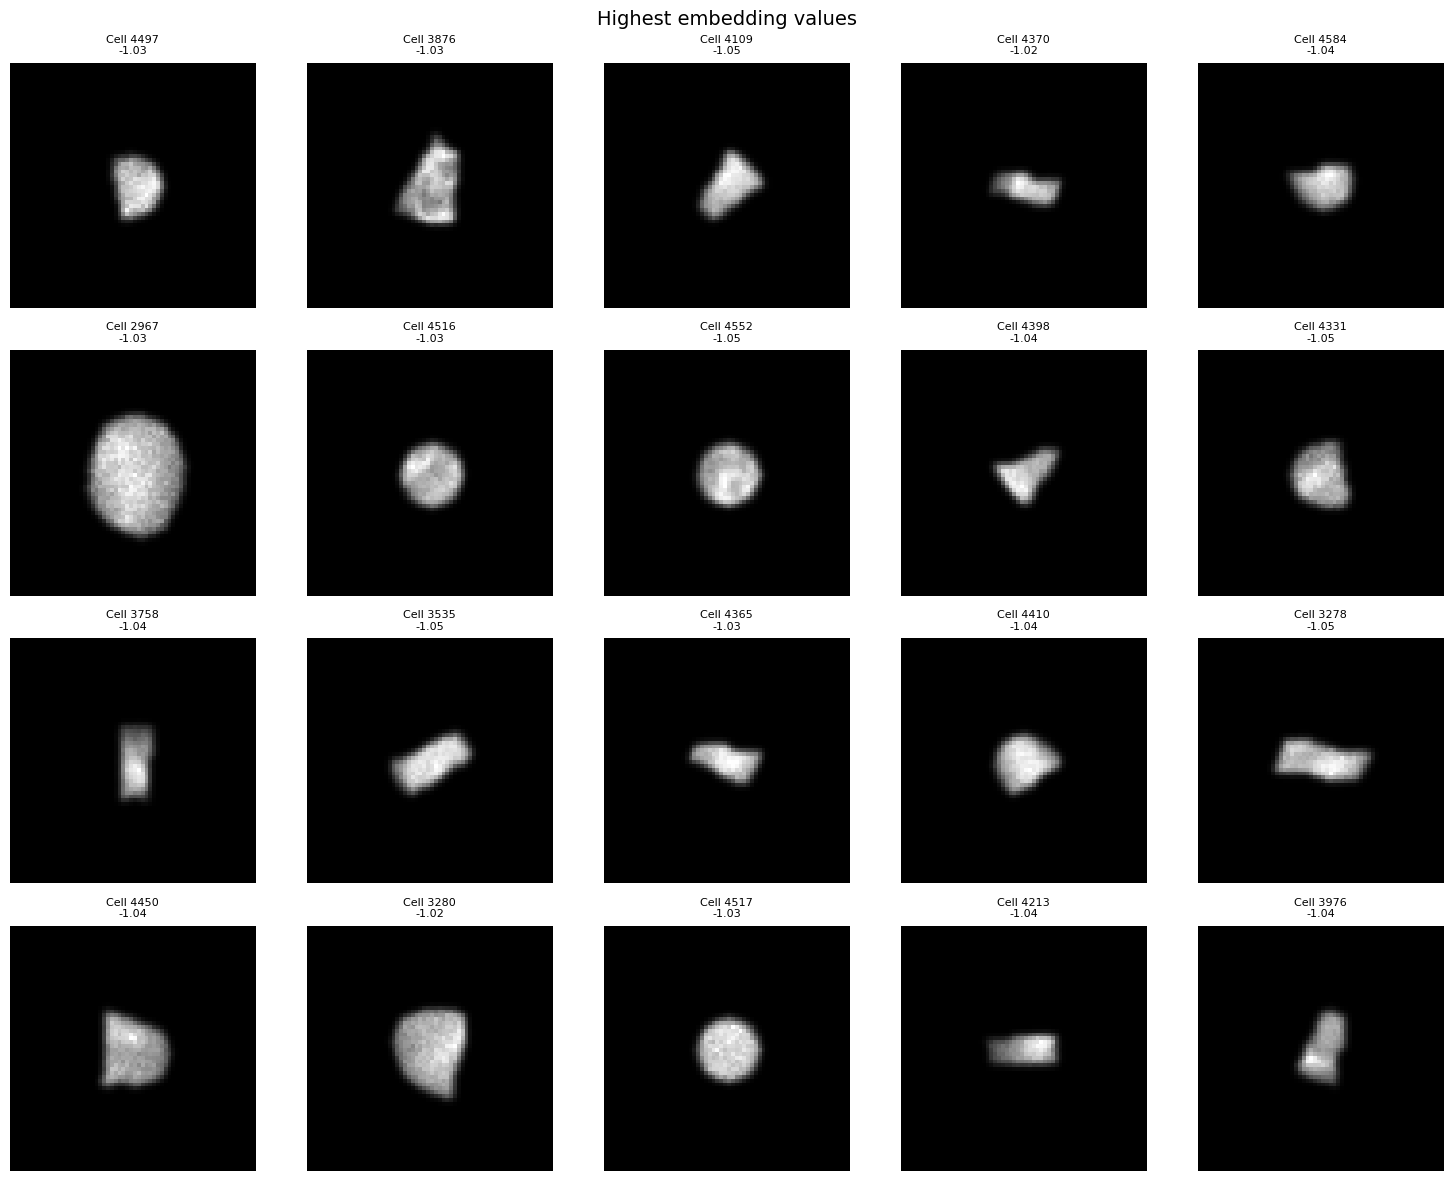

Embedding dimension: 558

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
0,nucleus_area,0.794158,0.000000e+00,0.794158
4,DAPI_quant25_nucleus,0.788219,0.000000e+00,0.788219
2,DAPI_median_nucleus,0.749374,0.000000e+00,0.749374
5,DAPI_summed_intensity_nucleus,0.700648,0.000000e+00,0.700648
1,DAPI_mean_nucleus,0.449097,6.407340e-201,0.449097
6,DAPI_summed_intensity_area_normalized_nucleus,0.449097,6.407340e-201,0.449097
3,DAPI_quant75_nucleus,0.319499,4.379249e-97,0.319499


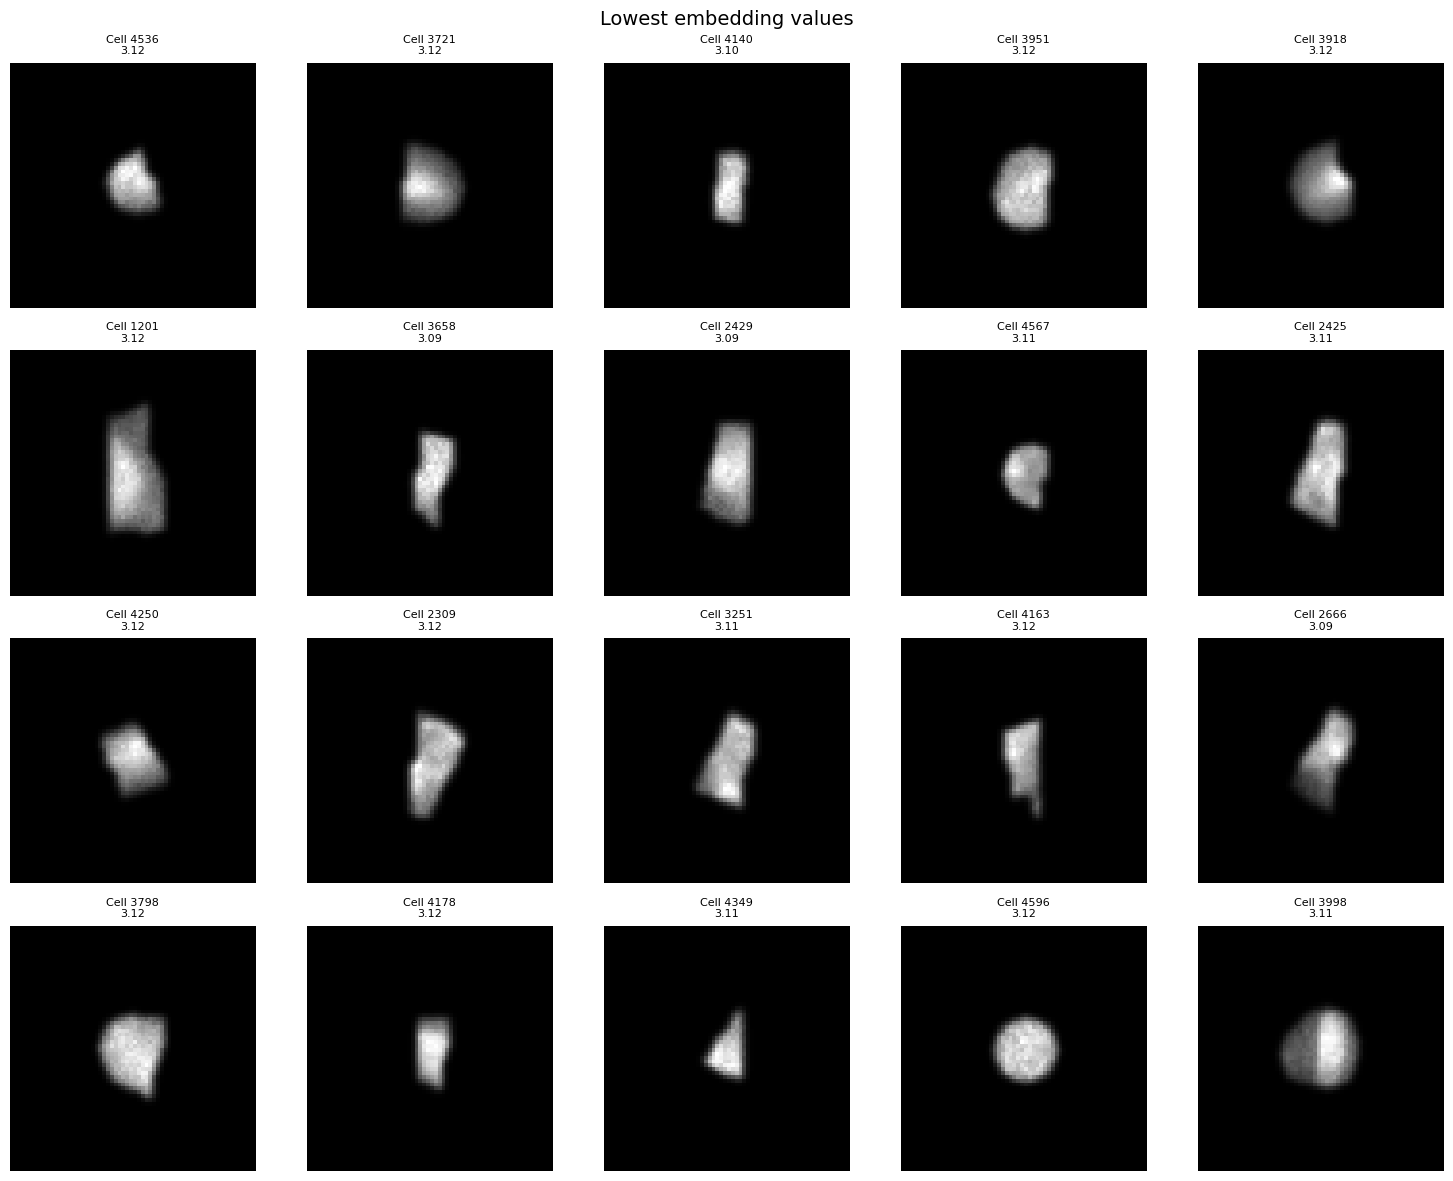

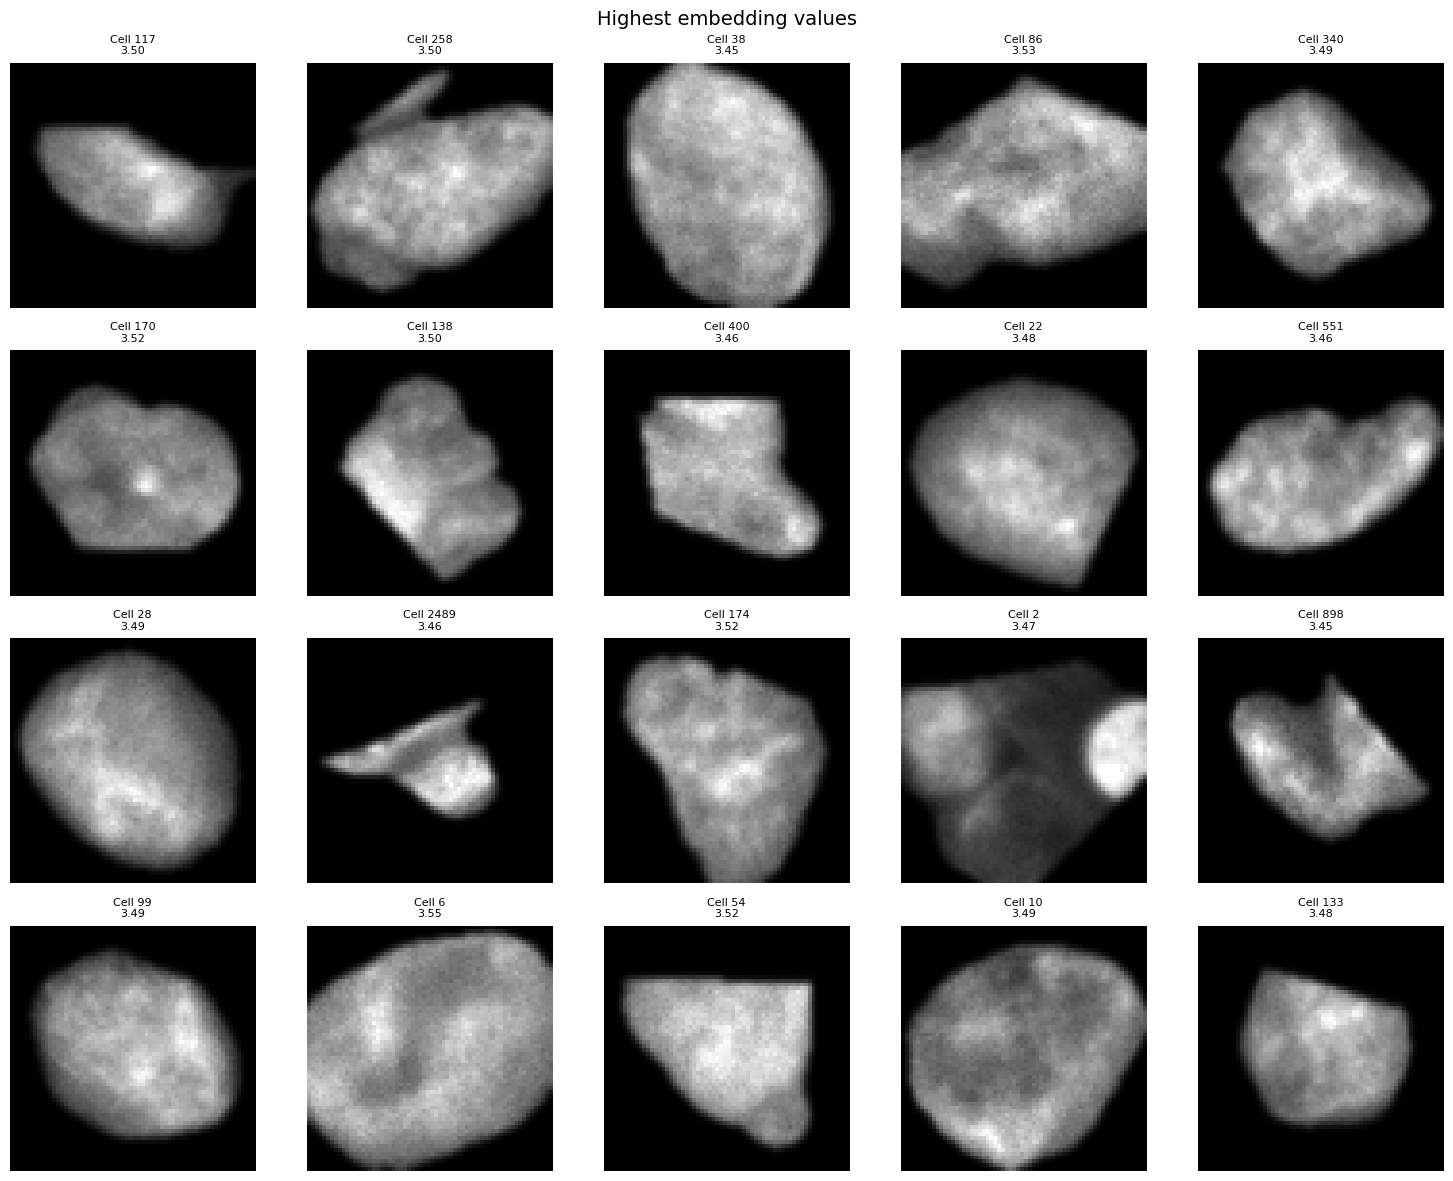

In [ ]:
top_embeddings = [103, 457, 304, 223, 558]

results = {}

for dim in top_embeddings:

    results[dim] = analyze_embedding_dimension(
        embedding_dim=dim,
        vit=vit,
        cellfeat=cellfeat,
        dataset=dataset,
        n_cells=20,
    )

# **ConvNeXt interpretation**

In [16]:
# Load the Anndata object containing the ConvNeXt embeddings
conv = sdata.tables["ConvNeXtFeaturizer_Ch1_nucleus"]

In [17]:
conv.obs.head(5)

,scportrait_cell_id,region
0,1,seg_all_nucleus
1,2,seg_all_nucleus
2,3,seg_all_nucleus
3,4,seg_all_nucleus
4,5,seg_all_nucleus


In [18]:
# Verify that both anndata objects describe the same set of cells
print(conv.shape)
print(cellfeat.shape)

print(
    np.all(
        conv.obs["scportrait_cell_id"].values ==
        cellfeat.obs["scportrait_cell_id"].values
    )
)

(4063, 2048)
(4063, 7)
True


In [19]:
image, _, dataset_cell_id = dataset[0]

print("Dataset cell ID:", int(dataset_cell_id))

print("AnnData cell ID:", conv.obs.iloc[0]["scportrait_cell_id"])

Dataset cell ID: 1
AnnData cell ID: 1


Embedding dimension: 379

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
0,nucleus_area,-0.138100,9.368462e-19,0.138100
3,DAPI_quant75_nucleus,0.107844,5.495585e-12,0.107844
2,DAPI_median_nucleus,-0.094925,1.340005e-09,0.094925
1,DAPI_mean_nucleus,0.088526,1.584208e-08,0.088526
6,DAPI_summed_intensity_area_normalized_nucleus,0.088526,1.584208e-08,0.088526
4,DAPI_quant25_nucleus,-0.049314,1.664996e-03,0.049314
5,DAPI_summed_intensity_nucleus,-0.028072,7.358955e-02,0.028072


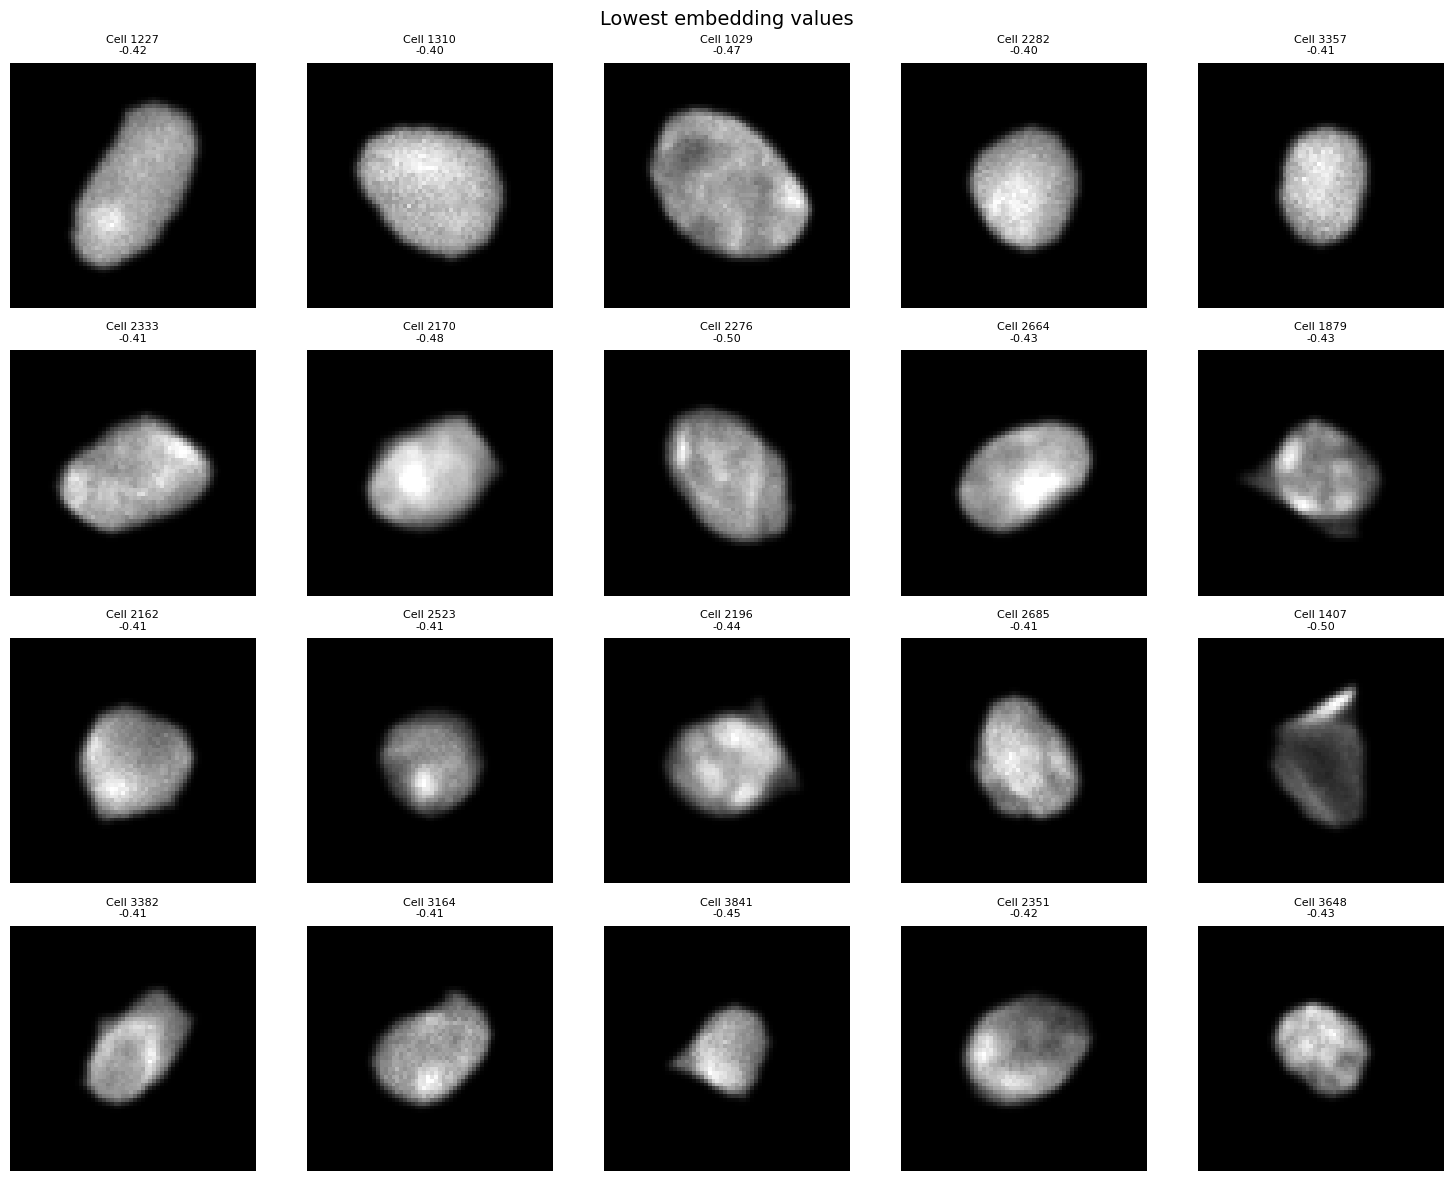

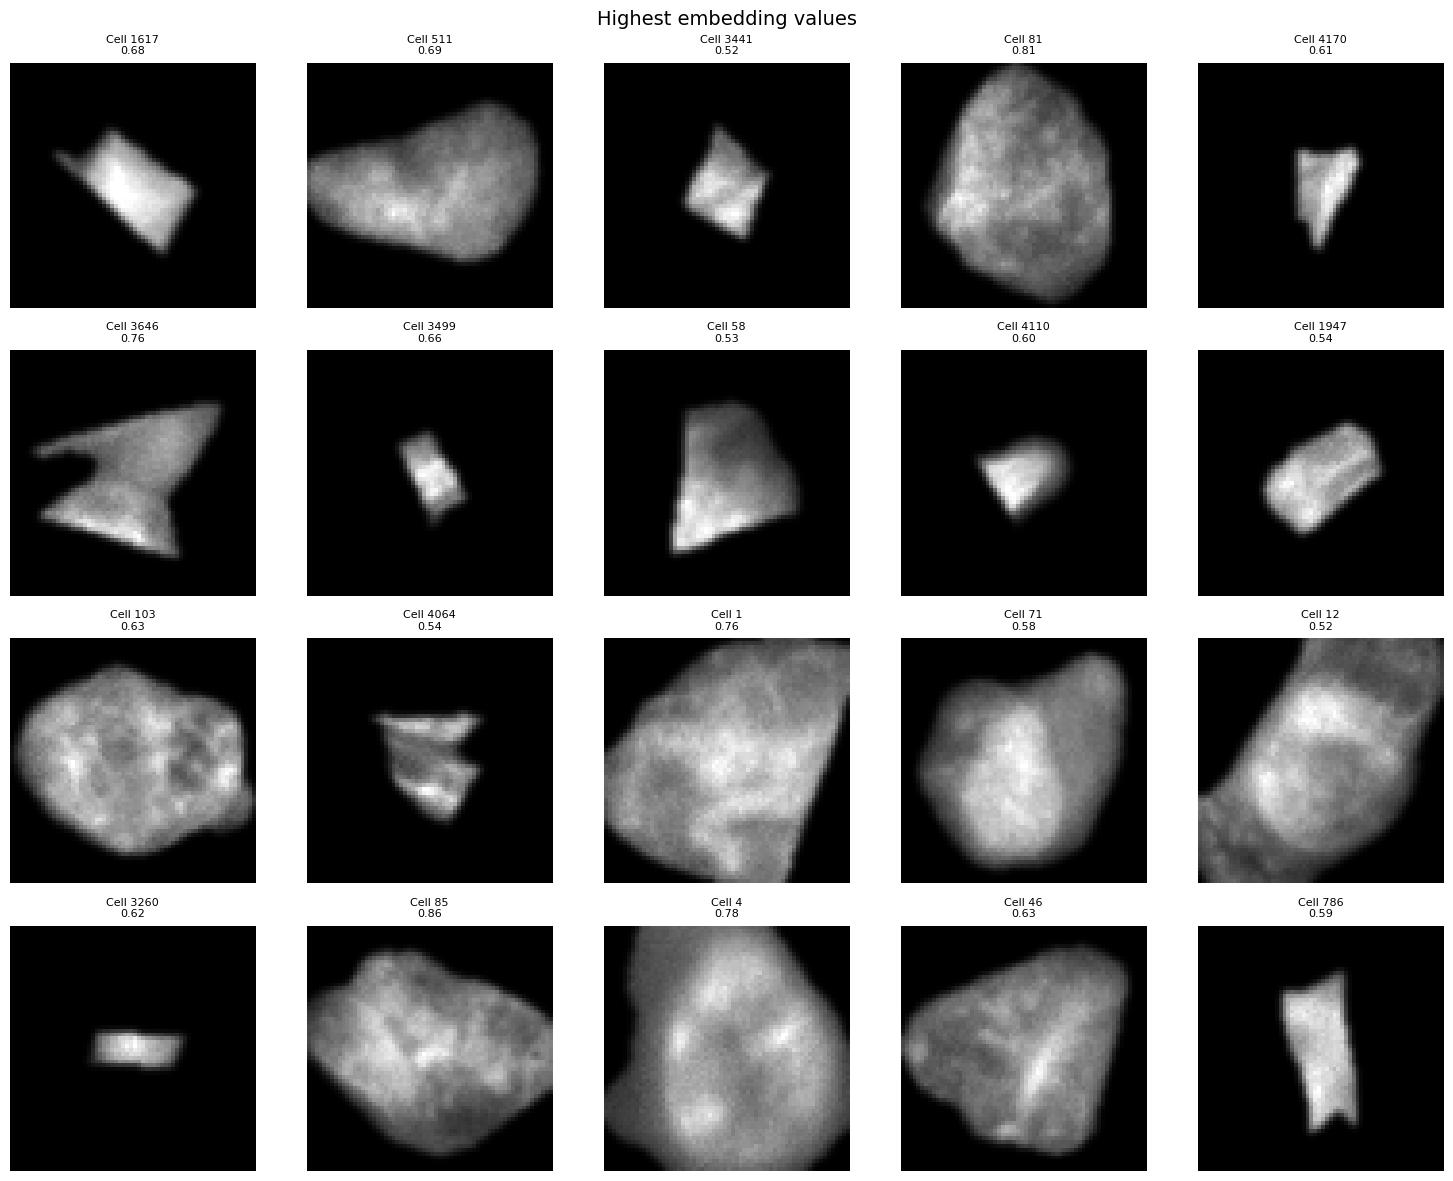

Embedding dimension: 1161

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
2,DAPI_median_nucleus,-0.666724,0.000000e+00,0.666724
0,nucleus_area,-0.653055,0.000000e+00,0.653055
4,DAPI_quant25_nucleus,-0.639713,0.000000e+00,0.639713
5,DAPI_summed_intensity_nucleus,-0.615208,0.000000e+00,0.615208
1,DAPI_mean_nucleus,-0.422554,1.061258e-175,0.422554
6,DAPI_summed_intensity_area_normalized_nucleus,-0.422554,1.061258e-175,0.422554
3,DAPI_quant75_nucleus,-0.324781,1.933553e-100,0.324781


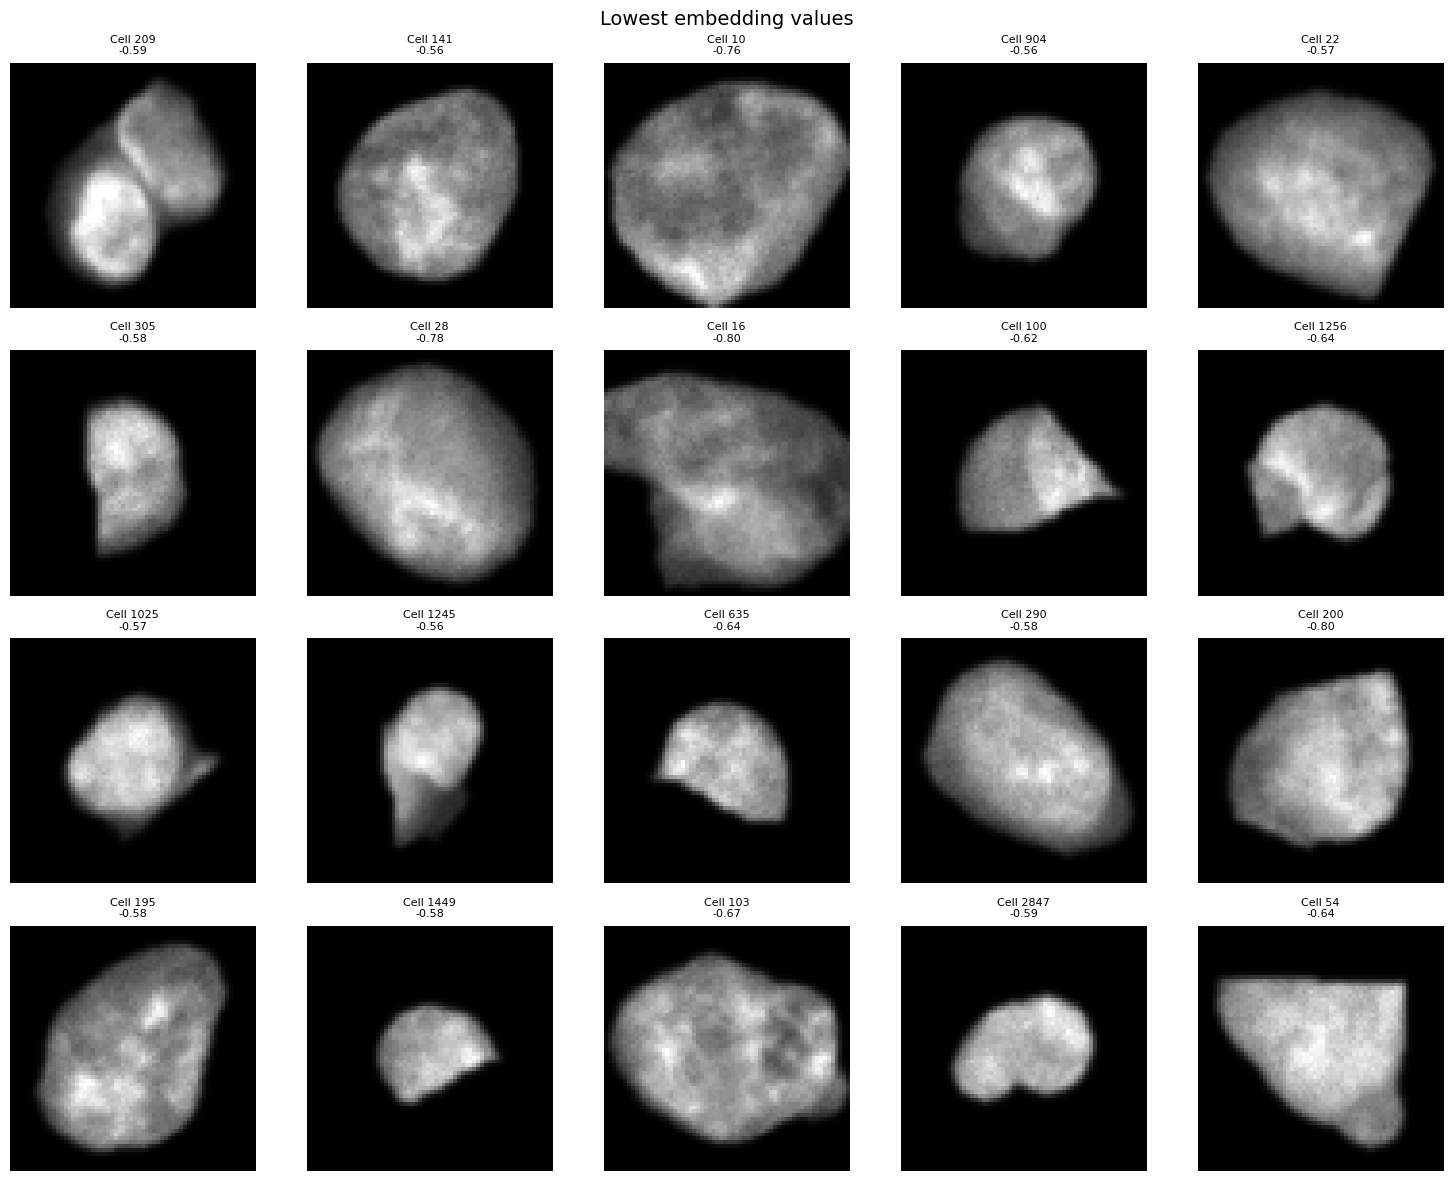

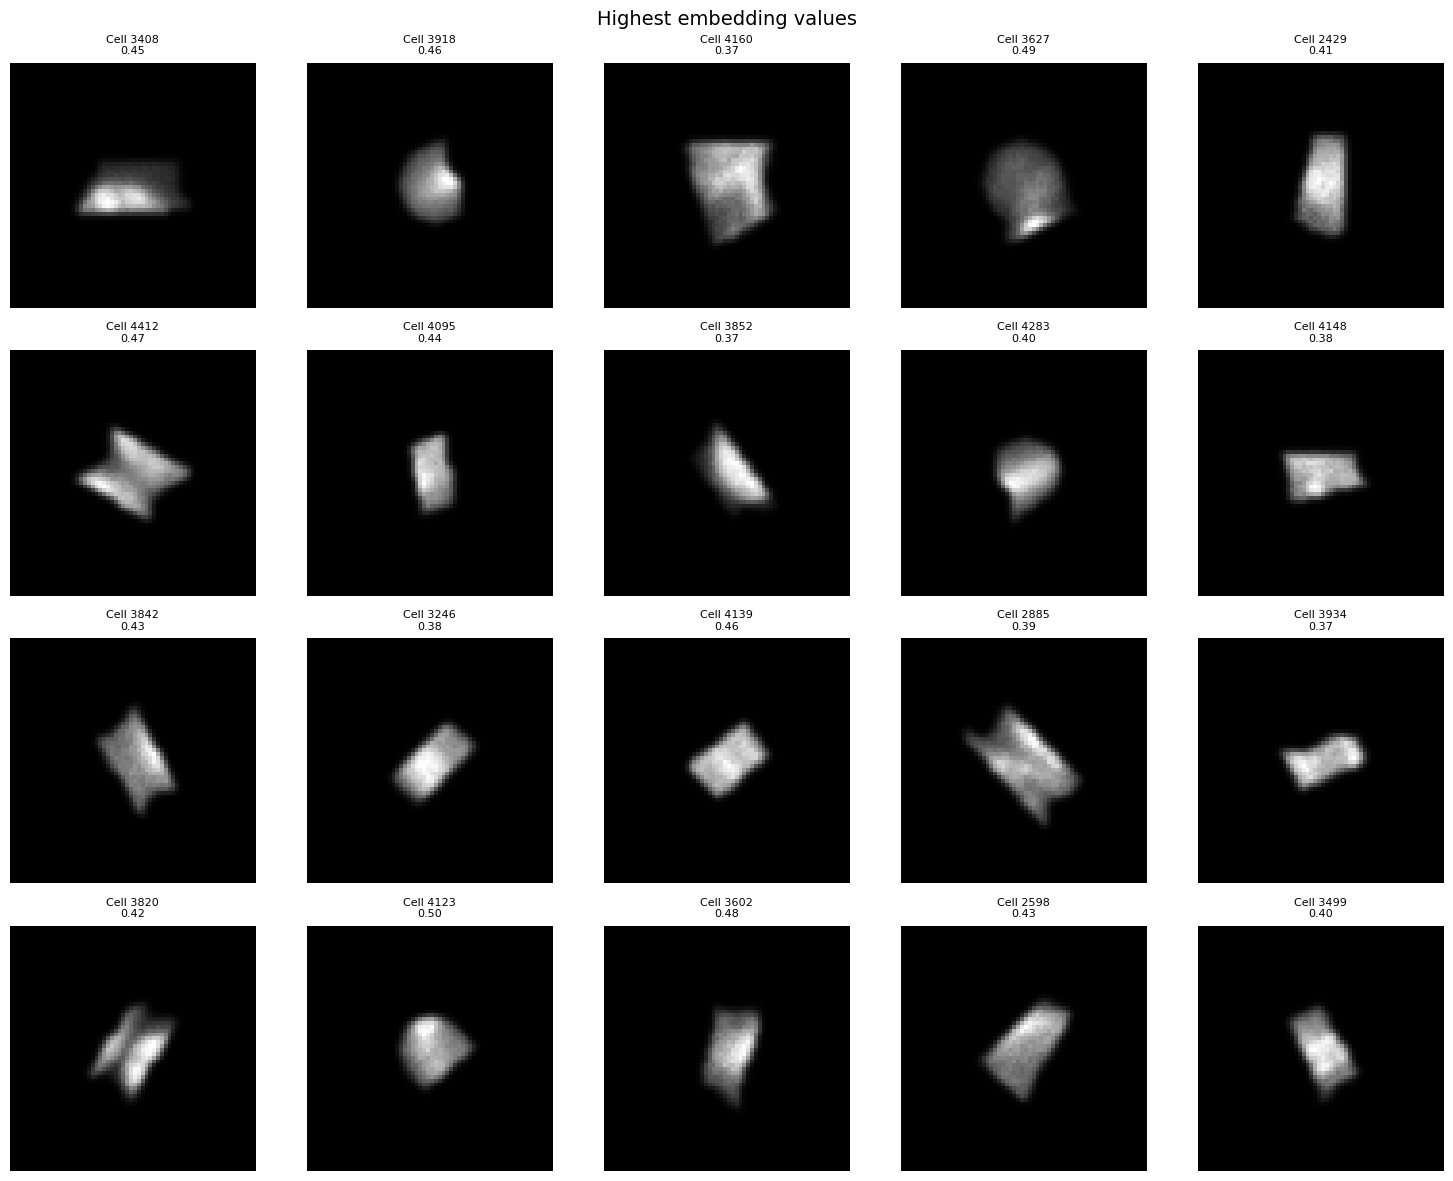

Embedding dimension: 46

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
0,nucleus_area,-0.410691,3.858615e-165,0.410691
4,DAPI_quant25_nucleus,-0.360555,5.418018e-125,0.360555
2,DAPI_median_nucleus,-0.339378,4.548853e-110,0.339378
5,DAPI_summed_intensity_nucleus,-0.289844,1.794546e-79,0.289844
1,DAPI_mean_nucleus,-0.082880,1.220616e-07,0.082880
6,DAPI_summed_intensity_area_normalized_nucleus,-0.082880,1.220616e-07,0.082880
3,DAPI_quant75_nucleus,-0.004326,7.828249e-01,0.004326


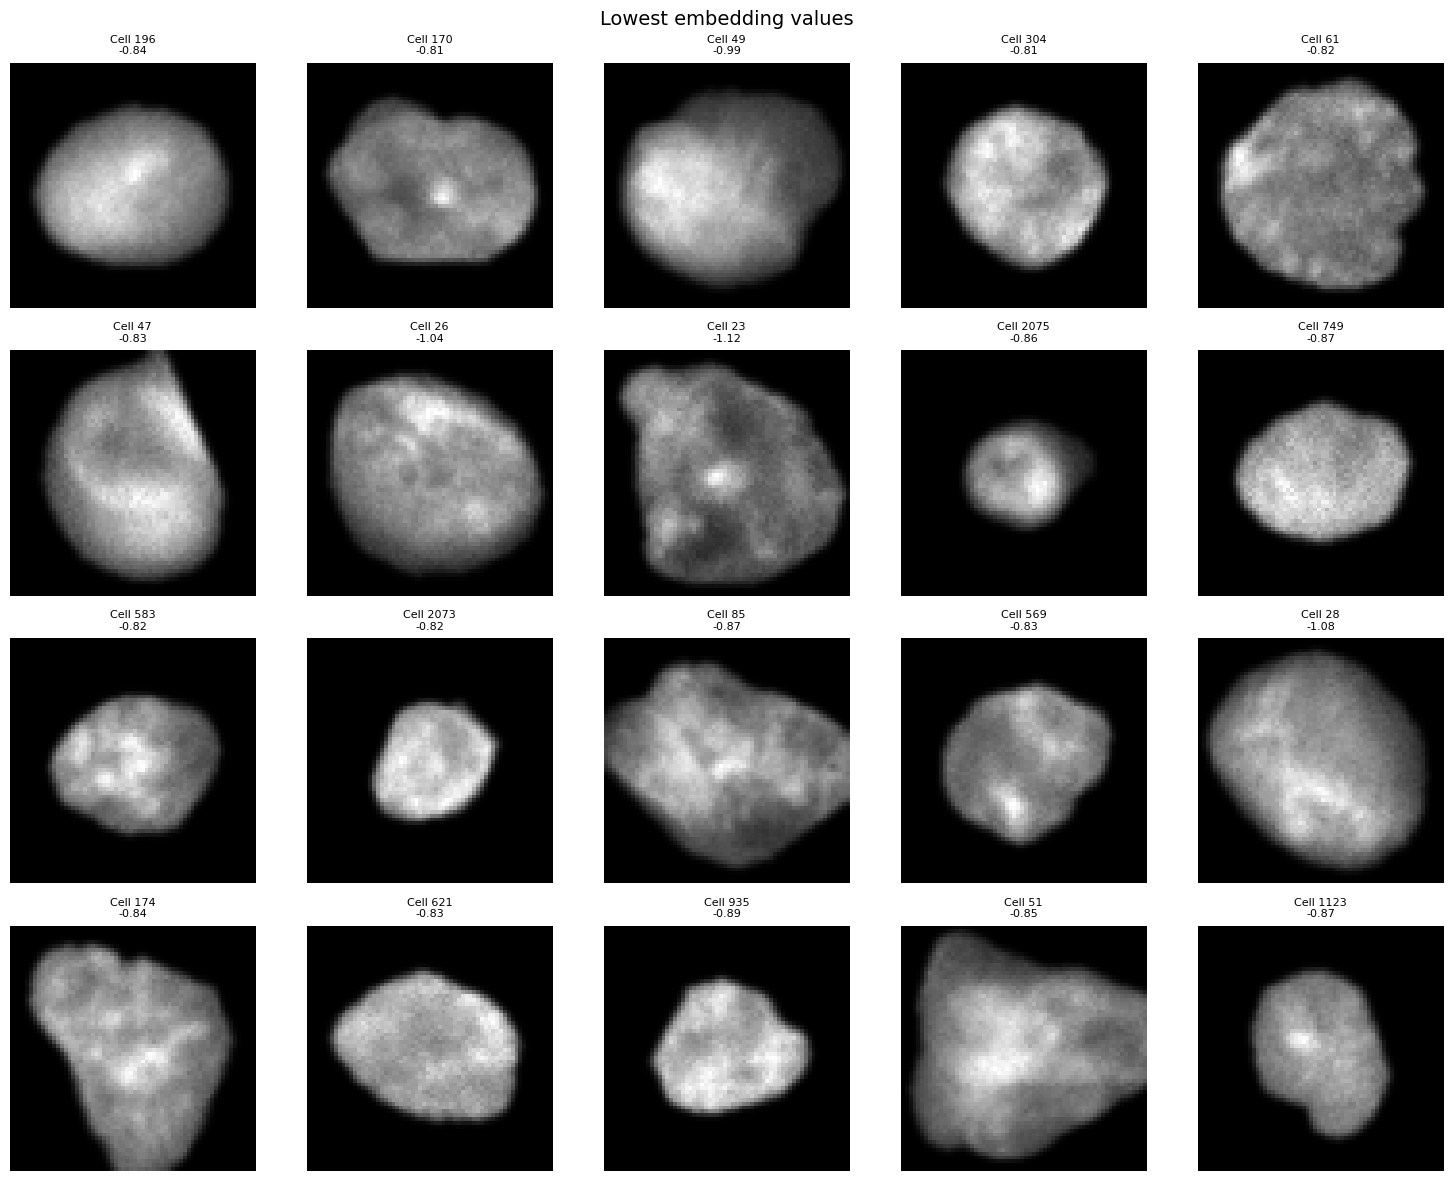

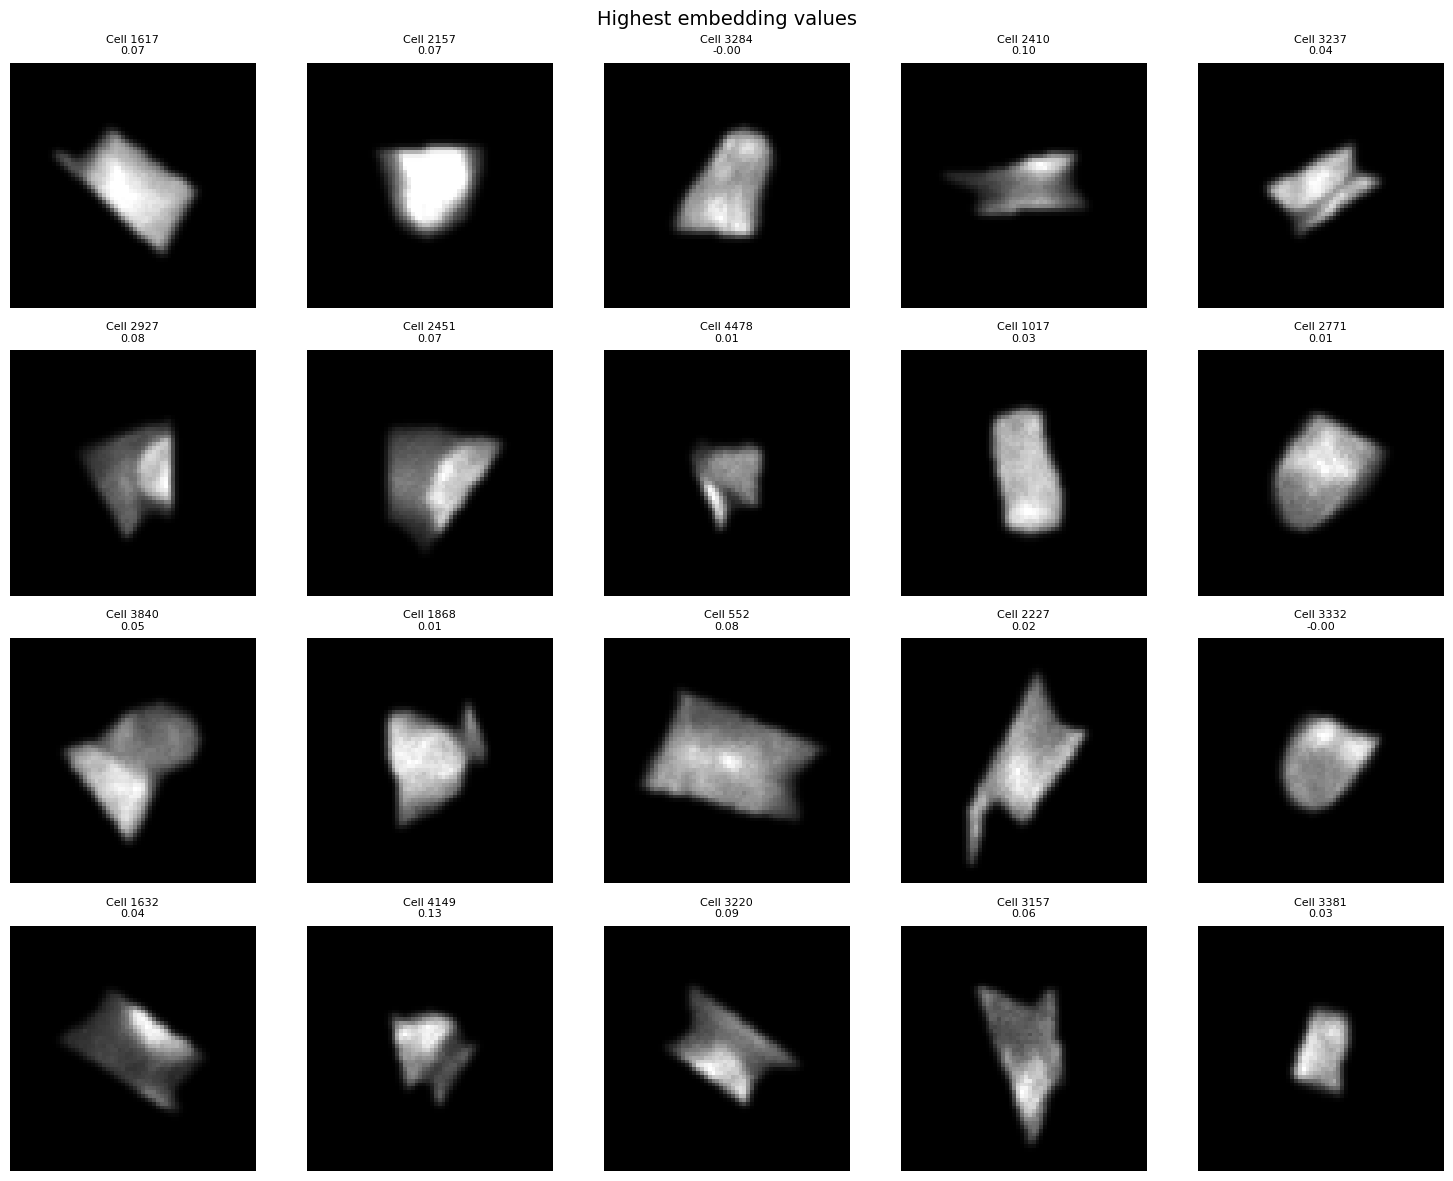

Embedding dimension: 1858

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
5,DAPI_summed_intensity_nucleus,0.674521,0.000000e+00,0.674521
2,DAPI_median_nucleus,0.669373,0.000000e+00,0.669373
0,nucleus_area,0.650943,0.000000e+00,0.650943
4,DAPI_quant25_nucleus,0.606912,0.000000e+00,0.606912
1,DAPI_mean_nucleus,0.526035,5.089226e-288,0.526035
6,DAPI_summed_intensity_area_normalized_nucleus,0.526035,5.089226e-288,0.526035
3,DAPI_quant75_nucleus,0.437399,1.581536e-189,0.437399


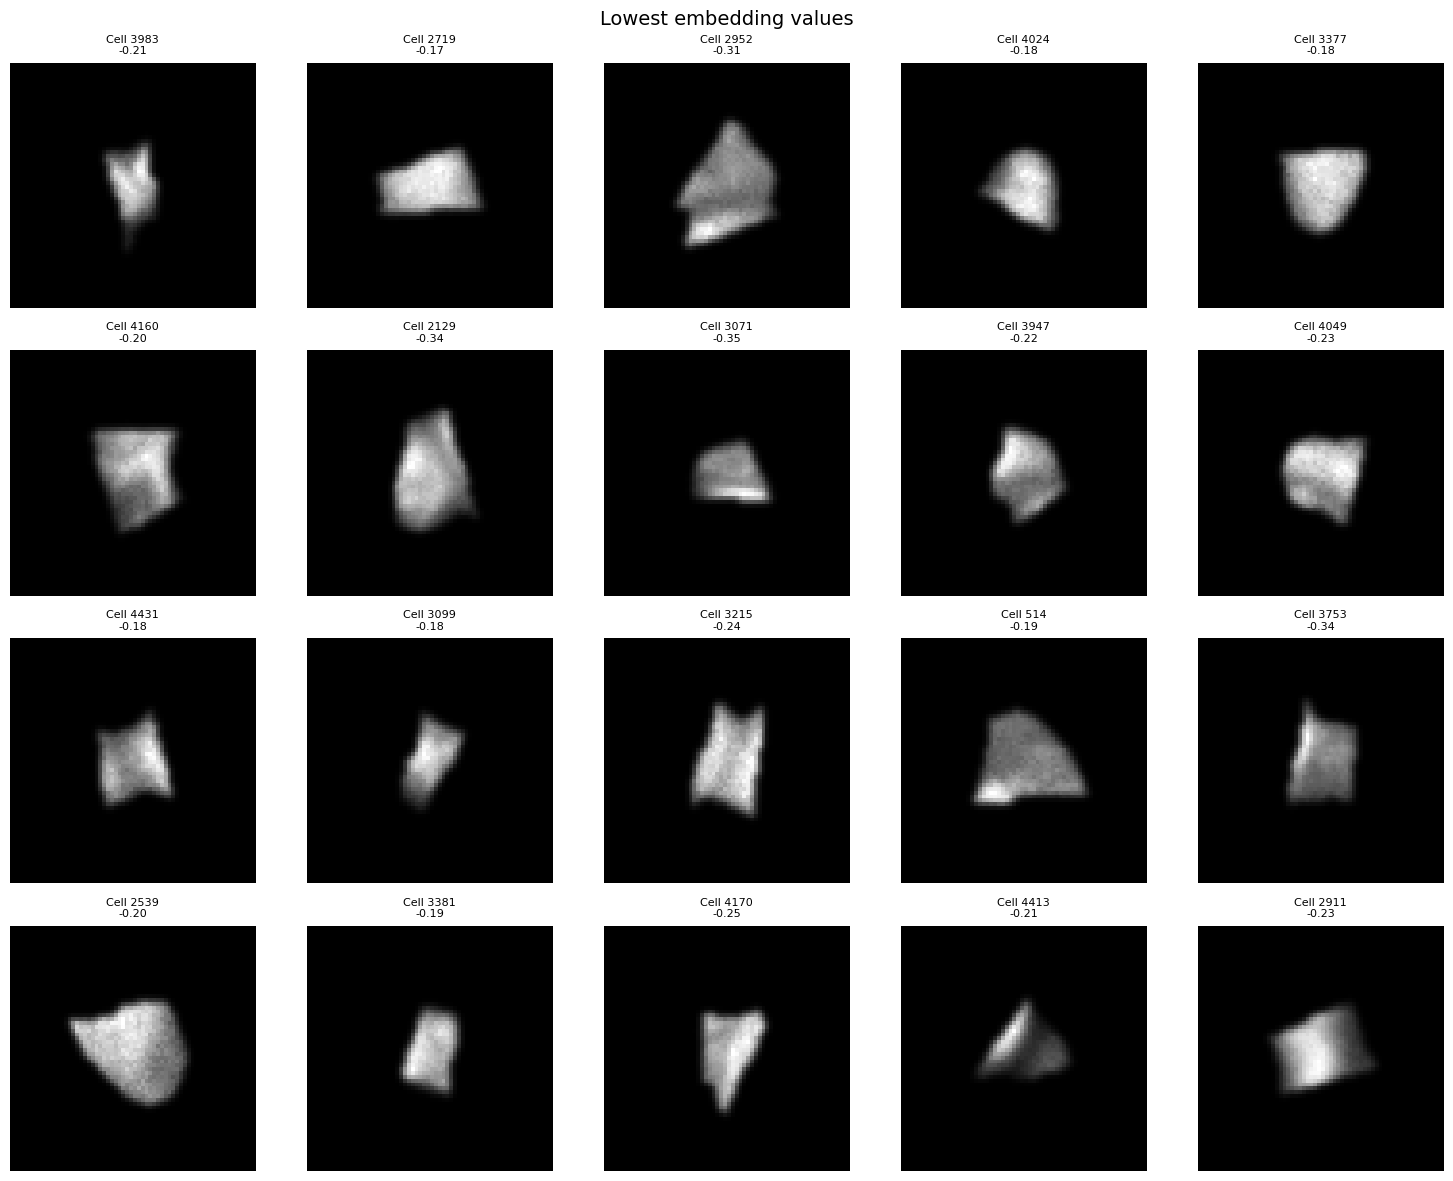

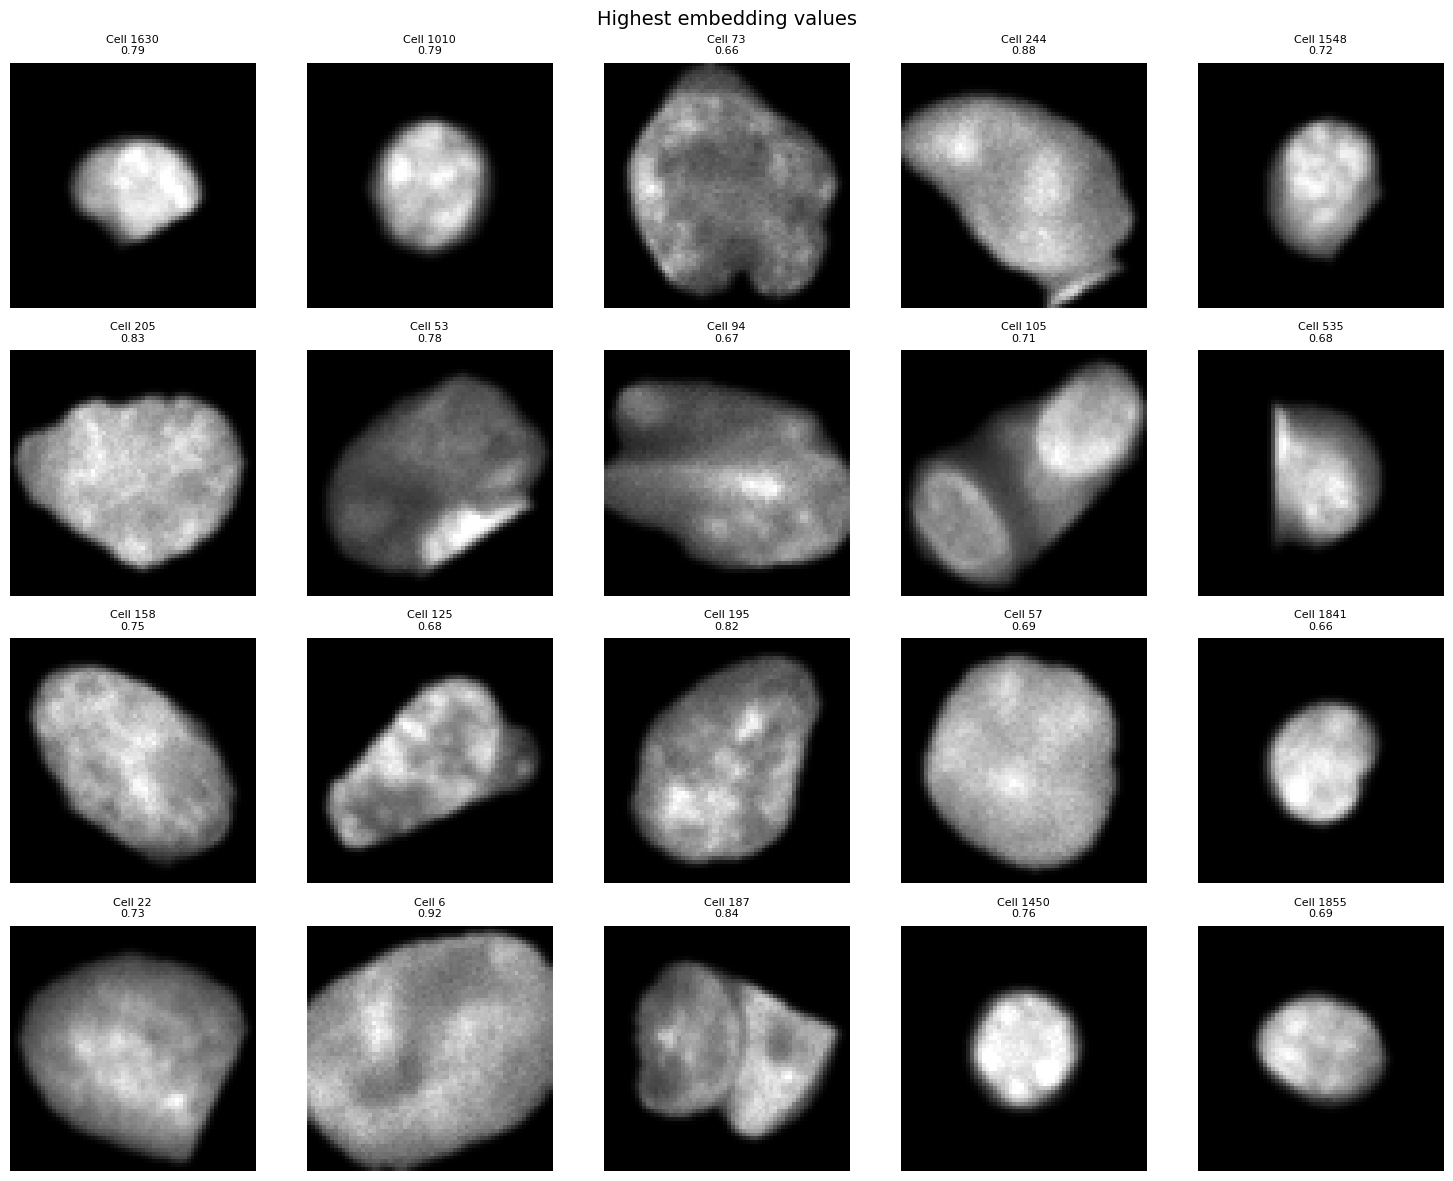

Embedding dimension: 967

Top correlated CellFeaturizer features



,Feature,Spearman_rho,P_value,Abs_rho
0,nucleus_area,-0.576973,0.000000e+00,0.576973
2,DAPI_median_nucleus,-0.520145,1.558090e-280,0.520145
4,DAPI_quant25_nucleus,-0.507976,1.580908e-265,0.507976
5,DAPI_summed_intensity_nucleus,-0.484072,9.207444e-238,0.484072
1,DAPI_mean_nucleus,-0.261764,1.215715e-64,0.261764
6,DAPI_summed_intensity_area_normalized_nucleus,-0.261764,1.215715e-64,0.261764
3,DAPI_quant75_nucleus,-0.173001,1.149006e-28,0.173001


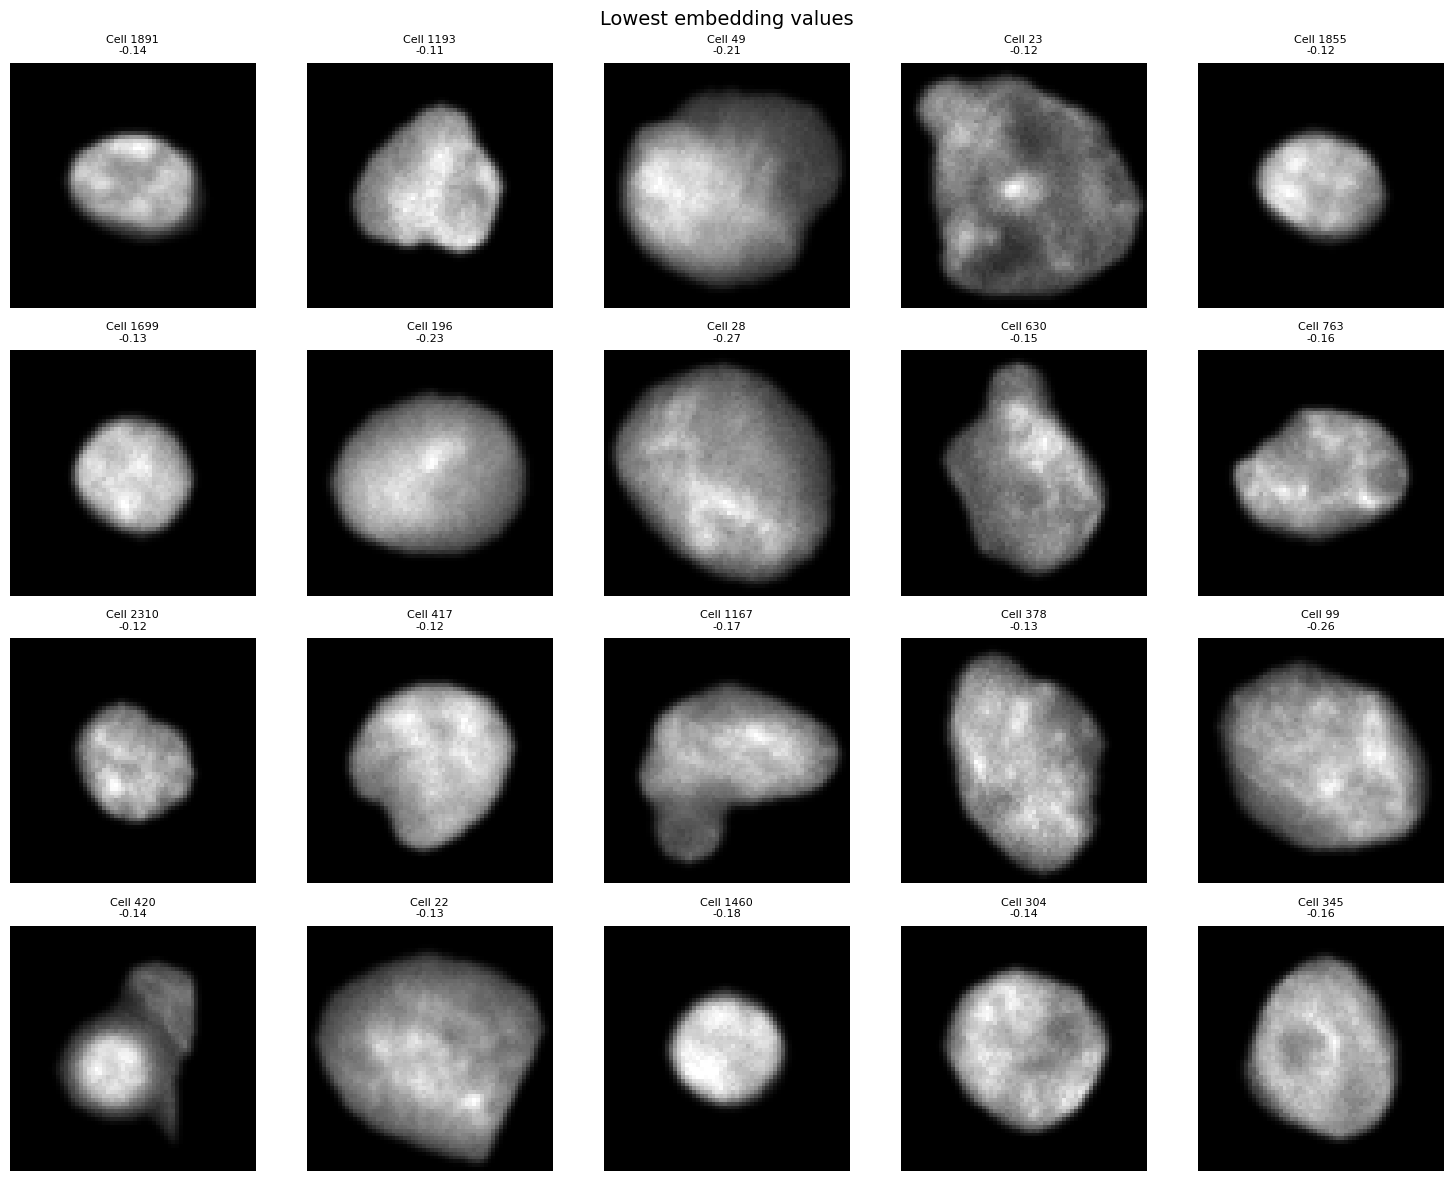

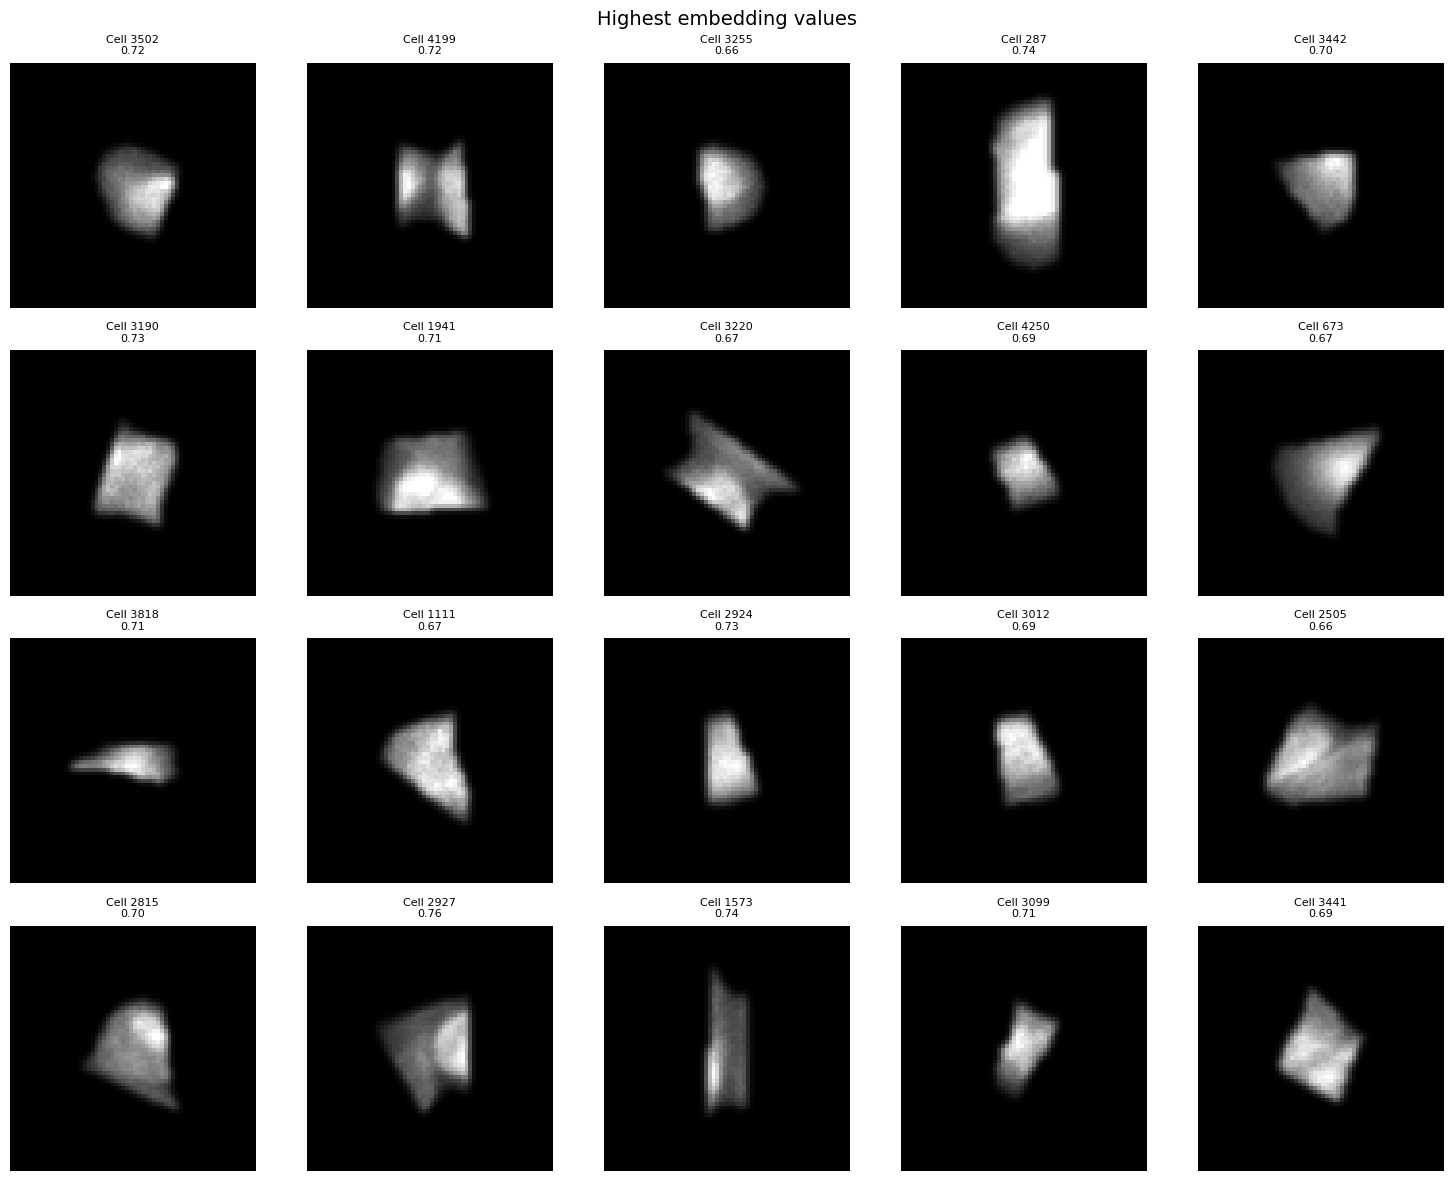

In [20]:
conv_top_embeddings = [379, 1161, 46, 1858, 967]

results = {}

for dim in conv_top_embeddings:

    results[dim] = analyze_embedding_dimension(
        embedding_dim=dim,
        vit=conv,
        cellfeat=cellfeat,
        dataset=dataset,
        n_cells=20,
    )